<a href="https://colab.research.google.com/github/akshayjoseph1999-maker/Akshay/blob/main/Normalized_Entanglement_Fidelity_benchmark_FINAL_clean_comments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Environment setup

%pip -q install \
    "qiskit==2.3.0" \
    "qiskit-aer==0.17.2" \
    "numpy==2.1.3" \
    "scipy==1.16.3" \
    "matplotlib==3.10.0"

import sys
import numpy as np
import scipy
import matplotlib
import qiskit
import qiskit_aer

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("\nSetup complete. Run Cell 2 next.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.0 MB/s eta 0:00:00
Python: 3.13.15
NumPy: 2.1.3
SciPy: 1.16.3
Matplotlib: 3.10.0
Qiskit: 2.3.0
Qiskit Aer: 0.17.2

Setup complete. Run Cell 2 next.


In [2]:
# QHWT simulation
# Task inputs are ideal baselines; gate-local noise is applied only to QHWT operations.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import DensityMatrix, Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    amplitude_damping_error,
    phase_damping_error,
)

# Reproducibility / global settings

SEED_TRANSPILE = 1234
SEED_SIM = 1234

# Factorized QHWT structure: H = H1 H2.
# H2 contains hierarchical shuffle/permutation layers and H1 contains
# conditional Hadamard layers. Qiskit little-endian indexing is used.


# Noise model: 1q amplitude+phase damping on 'u', 2q depolarizing on 'cx'

def build_noise_model(gamma_amp_1q=4e-5, gamma_phase_1q=6e-5, p2q=1e-3):
    """
    Gate-local phenomenological noise model:
      - Every 1q 'u' gate gets phase damping + amplitude damping
      - Every 2q 'cx' gate gets depolarizing noise

    The final circuits are forced into basis ['u','cx'] so these channels apply.
    """
    if not (0 <= gamma_amp_1q <= 1 and 0 <= gamma_phase_1q <= 1):
        raise ValueError("1q damping parameters must be in [0,1].")
    if not (0 <= p2q <= 1):
        raise ValueError("p2q must be in [0,1].")

    nm = NoiseModel()

    e1 = phase_damping_error(gamma_phase_1q).compose(
        amplitude_damping_error(gamma_amp_1q)
    )
    e2 = depolarizing_error(p2q, 2)

    nm.add_all_qubit_quantum_error(e1, "u")
    nm.add_all_qubit_quantum_error(e2, "cx")
    return nm


# QHWT layers (H2 then H1)

def perfect_shuffle_rotation_layer(n, active_i=None, controls_zero=None):
    """
    Implements a shuffle-like cyclic rotation on the first active_i qubits
    using adjacent SWAPs. If controls_zero is provided, the whole SWAP chain
    is controlled on those qubits being |0> (via X wrappers).

    This follows the same hierarchical-permutation style used in your previous code.
    """
    from qiskit.circuit.library import SwapGate

    qc = QuantumCircuit(n)
    if active_i is None:
        active_i = n
    if active_i <= 1:
        return qc

    controls_zero = controls_zero or []
    k = len(controls_zero)

    # Convert control-on-|0> to control-on-|1> by X wrappers
    for c in controls_zero:
        qc.x(c)

    for s in range(active_i - 1):
        q1, q2 = s, s + 1
        if k == 0:
            qc.swap(q1, q2)
        else:
            gate = SwapGate().control(k)
            qc.append(gate, controls_zero + [q1, q2])

    for c in controls_zero:
        qc.x(c)

    return qc


def h2_layers(n):
    """
    H^(2): hierarchy of shuffle/permutation blocks
      - unconditional shuffle on first n qubits
      - then conditional shuffles on prefixes, controlled on higher qubits = |0>
    """
    layers = []
    layers.append(
        (perfect_shuffle_rotation_layer(n, active_i=n, controls_zero=None), f"H2_Pi_2^{n}")
    )
    for i in range(n - 1, 1, -1):
        controls_zero = list(range(i, n))  # qubits i..n-1 must be |0>
        layers.append(
            (
                perfect_shuffle_rotation_layer(n, active_i=i, controls_zero=controls_zero),
                f"H2_condPi_2^{i}",
            )
        )
    return layers


def h1_layers_conditional_W(n):
    """
    H^(1): nested conditional Walsh-Hadamard kernels.
    Hadamard on target qubit q0, conditioned on progressively more qubits = |0>.
    """
    from qiskit.circuit.library import HGate

    layers = []
    target = 0  # LSB in Qiskit indexing

    for i in range(1, n + 1):
        # controls are the top (i-1) qubits
        controls = list(range(n - (i - 1), n))
        qc = QuantumCircuit(n)

        if len(controls) == 0:
            qc.h(target)
        else:
            # control on |0> via X wrappers
            for c in controls:
                qc.x(c)
            gate = HGate().control(len(controls))
            qc.append(gate, controls + [target])
            for c in controls:
                qc.x(c)

        layers.append((qc, f"H1_condW_i={i}"))

    return layers


def build_qhwt_layers(n):
    # Overall factorized transform: H = H1 * H2
    return h2_layers(n) + h1_layers_conditional_W(n)


# Inputs + ideal targets (include k=0 snapshot)

def prepare_input_state(qc, n, input_type="ghz"):
    t = input_type.lower()
    if t == "ghz":
        qc.h(0)
        for k in range(n - 1):
            qc.cx(k, k + 1)
    elif t == "zero":
        # |0...0> already prepared by default
        pass
    else:
        raise ValueError("input_type must be 'ghz' or 'zero'")


def ideal_targets_by_step_with_k0(n, layers, input_type="ghz"):
    """
    Returns ideal pure targets for:
      k=0: after input preparation (before QHWT layers)
      k=1..M: after each QHWT prefix layer
    """
    qc = QuantumCircuit(n)
    prepare_input_state(qc, n, input_type=input_type)

    targets = [Statevector.from_instruction(qc).data]
    for lay, _ in layers:
        qc.compose(lay, inplace=True)
        targets.append(Statevector.from_instruction(qc).data)
    return targets


def ideal_input_density_matrix(n, input_type="ghz"):
    """
    Prepare the task input ideally and return its density matrix.

    IMPORTANT:
    The input-preparation gates are NOT included in the noisy circuit.
    Therefore:
      - generation starts from exact |0...0><0...0|
      - robustness starts from an exact GHZ density matrix

    Noise is applied only to the QHWT transform itself.
    """
    qc = QuantumCircuit(n)
    prepare_input_state(qc, n, input_type=input_type)
    psi = Statevector.from_instruction(qc)
    return DensityMatrix(psi).data


# Entanglement + fidelity

def half_cut_subsystems(n):
    half = n // 2
    A = list(range(half))
    B = list(range(half, n))
    return A, B


def log_negativity_halfcut(rho_np, n):
    """
    E_N = log2 || rho^{T_B} ||_1
    """
    _, B = half_cut_subsystems(n)
    dm = DensityMatrix(rho_np)
    dm_pt = dm.partial_transpose(B)
    eigs = np.linalg.eigvalsh(dm_pt.data)
    tr_norm = float(np.sum(np.abs(np.real_if_close(eigs))))
    return float(np.log2(max(tr_norm, 1e-15)))


def fidelity_pure_to_rho(psi, rho_np):
    psi = np.asarray(psi, dtype=complex).reshape((-1, 1))
    return float(np.real_if_close((psi.conj().T @ rho_np @ psi)[0, 0]))


# Transpile helpers (force basis so noise attaches)

def _force_decompose_to_u_cx(qc, opt_level=1, reps=30):
    qc2 = qc.decompose(reps=reps)
    tqc = transpile(
        qc2,
        basis_gates=["u", "cx"],
        optimization_level=opt_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    return tqc


def cx_count(circ):
    return int(circ.count_ops().get("cx", 0))


# Prefix noisy simulation (include k=0 and cost split)

def simulate_prefix_rhos_with_k0(
    n,
    layers,
    input_type,
    noise_model,
    opt_level=1,
    reps=30,
):
    """
    Simulate the QHWT starting from an IDEAL task input.

    k=0:
        exact ideal input density matrix, before any QHWT layer.

    k=1..M:
        ideal input -> noisy compiled QHWT prefix.

    The input-preparation circuit itself is NOT passed through the noise model.
    This makes the robustness task a true "pre-entangled input" test:
        ideal GHZ -> noisy QHWT.

    Returns:
      rhos:       density matrices for k=0..M
      N2q_total:  compiled CX count of the QHWT prefix
      N2q_qhwt:   same QHWT-only CX count (kept for interface compatibility)
    """
    sim = AerSimulator(
        method="density_matrix",
        noise_model=noise_model,
        seed_simulator=SEED_SIM,
    )

    # Ideal task input; preparation noise is excluded.
    rho_init = np.array(
        ideal_input_density_matrix(n, input_type=input_type),
        dtype=complex,
    )

    rhos = [rho_init.copy()]
    N2q_total = [0]
    N2q_qhwt = [0]

    # Build the QHWT prefix; input preparation is excluded from the noisy circuit.
    qhwt_prefix = QuantumCircuit(n)

    for lay, _ in layers:
        qhwt_prefix.compose(lay, inplace=True)

        # Decompose/transpile only the QHWT operations into {u, cx}.
        tprefix = _force_decompose_to_u_cx(
            qhwt_prefix,
            opt_level=opt_level,
            reps=reps,
        )
        qhwt_cx = cx_count(tprefix)

        # Start the density-matrix simulation from the ideal input state.
        circ_run = QuantumCircuit(n)
        circ_run.set_density_matrix(DensityMatrix(rho_init))
        circ_run.compose(tprefix, inplace=True)
        circ_run.save_density_matrix(label="rho")

        res = sim.run(circ_run).result()
        rho = np.array(res.data(0)["rho"], dtype=complex)

        rhos.append(rho)
        N2q_total.append(qhwt_cx)
        N2q_qhwt.append(qhwt_cx)

    return (
        rhos,
        np.array(N2q_total, dtype=int),
        np.array(N2q_qhwt, dtype=int),
    )


# One-task runner (generation or robustness)

def run_task_qhwt(
    n,
    input_type,
    gamma_amp,
    gamma_phase,
    p2q,
    opt_level=1,
):
    layers = build_qhwt_layers(n)
    targets = ideal_targets_by_step_with_k0(n, layers, input_type=input_type)

    nm = build_noise_model(
        gamma_amp_1q=gamma_amp,
        gamma_phase_1q=gamma_phase,
        p2q=p2q,
    )

    rhos, N2q_total, N2q_qhwt = simulate_prefix_rhos_with_k0(
        n=n,
        layers=layers,
        input_type=input_type,
        noise_model=nm,
        opt_level=opt_level,
        reps=30,
    )

    Elog = np.array([log_negativity_halfcut(rho, n) for rho in rhos], dtype=float)
    F = np.array([fidelity_pure_to_rho(targets[k], rhos[k]) for k in range(len(rhos))], dtype=float)

    # Per-prefix normalized trajectories (QHWT-only cost; input state is ideal)
    E_per_ent = np.zeros_like(Elog)
    F_per_ent = np.zeros_like(F)

    for k in range(1, len(Elog)):
        denom = max(float(N2q_qhwt[k]), 1e-12)
        E_per_ent[k] = -(Elog[k] - Elog[0]) / denom           # +ve means loss
        F_per_ent[k] = (F[0] - F[k]) / denom                  # +ve means loss

    return {
        "N2q_total": N2q_total,
        "N2q_qhwt": N2q_qhwt,    # QHWT-only entangler count
        "Elog": Elog,
        "F": F,
        "E_per_ent": E_per_ent,  # per-entangler entanglement loss trajectory
        "F_per_ent": F_per_ent,  # per-entangler fidelity loss trajectory
        "layers_count": len(layers),
    }


# Phase-point summary (uses k=0 baseline + QHWT-only cost)

def phase_point_from_task(out):
    """
    x = -ΔE_N / N2q_qhwt(final)
    y =  ΔF   / N2q_qhwt(final)

    where:
      ΔE_N = E_final - E_k0
      ΔF   = F_k0 - F_final
    """
    N2q = max(float(out["N2q_qhwt"][-1]), 1e-12)
    dE = float(out["Elog"][-1] - out["Elog"][0])
    dF = float(out["F"][0] - out["F"][-1])

    x = (-dE) / N2q  # entanglement loss per entangler (+ve means net loss)
    y = (dF) / N2q   # fidelity loss per entangler (+ve means net loss)
    return x, y


# Sweep phase points for 3 noise regimes (2Q noisier than 1Q)

def run_phase_sweep_two_tasks(
    n_min=2,
    n_max=6,
    p1_base=1e-4,       # effective 1q total noise scale
    amp_frac=0.4,
    phase_frac=0.6,
    ratios_2q_over_1q=(10, 100, 1000),
    opt_level=1,
):
    """
    p1_base is split into:
      gamma_amp   = amp_frac * p1_base
      gamma_phase = phase_frac * p1_base

    and 2q depolarizing is:
      p2q = ratio * p1_base

    ratios are chosen so 2q gates are 10x, 100x, 1000x noisier than 1q scale.
    """
    if abs((amp_frac + phase_frac) - 1.0) > 1e-12:
        raise ValueError("Use amp_frac + phase_frac = 1.0 for a clean 1q noise split.")

    gamma_amp = amp_frac * p1_base
    gamma_phase = phase_frac * p1_base

    regime_data = {}

    for ratio in ratios_2q_over_1q:
        p2q = ratio * p1_base
        if p2q > 1:
            raise ValueError(
                f"p2q = {p2q} exceeds 1. Reduce p1_base or ratio."
            )

        regime_name = f"2Q noise = {ratio}x 1Q scale"

        print(
            f"\n=== {regime_name} | "
            f"gamma_amp={gamma_amp:.3e}, gamma_phase={gamma_phase:.3e}, p2q={p2q:.3e} ==="
        )

        regime_data[regime_name] = {
            "meta": {
                "ratio_2q_over_1q": ratio,
                "p1_base": p1_base,
                "gamma_amp": gamma_amp,
                "gamma_phase": gamma_phase,
                "p2q": p2q,
            },
            "generation": [],  # (x, y, n)
            "robustness": [],  # (x, y, n)
        }

        for n in range(n_min, n_max + 1):
            print(f"  Running n={n} ...")

            # Generation task: |0...0>
            out_gen = run_task_qhwt(
                n=n,
                input_type="zero",
                gamma_amp=gamma_amp,
                gamma_phase=gamma_phase,
                p2q=p2q,
                opt_level=opt_level,
            )
            xg, yg = phase_point_from_task(out_gen)
            regime_data[regime_name]["generation"].append((xg, yg, n))

            # Robustness task: GHZ
            out_rob = run_task_qhwt(
                n=n,
                input_type="ghz",
                gamma_amp=gamma_amp,
                gamma_phase=gamma_phase,
                p2q=p2q,
                opt_level=opt_level,
            )
            xr, yr = phase_point_from_task(out_rob)
            regime_data[regime_name]["robustness"].append((xr, yr, n))

    return regime_data


# Plotting: one phase plot per noise regime

def _style_symlog_axes(ax, linthresh_x=1e-4, linthresh_y=1e-5):
    ax.set_xscale("symlog", linthresh=linthresh_x)
    ax.set_yscale("symlog", linthresh=linthresh_y)

    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)

    ax.grid(True, which="both", alpha=0.25)


def plot_phase_per_regime(regime_data, label_ns=(2, 4, 6)):
    """
    Creates 3 separate figures (one for each noise regime).
    Each figure shows:
      - Generation task points/curve across n
      - Robustness task points/curve across n
    """
    for regime_name, data in regime_data.items():
        fig, ax = plt.subplots(figsize=(7.8, 5.0))

        # Generation curve
        gen_pts = sorted(data["generation"], key=lambda t: t[2])
        gx = [p[0] for p in gen_pts]
        gy = [p[1] for p in gen_pts]
        gn = [p[2] for p in gen_pts]
        ax.plot(gx, gy, "-o", markersize=4, label="Generation task (|0⟩^n)")

        # Robustness curve
        rob_pts = sorted(data["robustness"], key=lambda t: t[2])
        rx = [p[0] for p in rob_pts]
        ry = [p[1] for p in rob_pts]
        rn = [p[2] for p in rob_pts]
        ax.plot(rx, ry, "-s", markersize=4, label="Robustness task (GHZ)")

        # Annotate selected n values
        for x, y, n in gen_pts:
            if n in label_ns:
                ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
        for x, y, n in rob_pts:
            if n in label_ns:
                ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(6, -12), fontsize=9)

        ax.set_xlabel(r"$x = -\Delta E_N / N_{2q}^{\mathrm{QHWT}}$  (entanglement loss per entangler)")
        ax.set_ylabel(r"$y = \Delta F / N_{2q}^{\mathrm{QHWT}}$  (fidelity loss per entangler)")
        ax.set_title(f"QHWT phase plot | {regime_name} | n=2..6")

        _style_symlog_axes(ax)

        # Put noise values in subtitle-style text box
        meta = data["meta"]
        txt = (
            rf"$\gamma_{{amp}}={meta['gamma_amp']:.1e}$, "
            rf"$\gamma_{{phase}}={meta['gamma_phase']:.1e}$, "
            rf"$p_{{2q}}={meta['p2q']:.1e}$"
        )
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9)
        )

        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
        plt.tight_layout()
        plt.show()


# Numerical phase summary

def print_phase_summary(regime_data):
    print("\n" + "=" * 90)
    print("PHASE SUMMARY (x = entanglement-loss/entangler, y = fidelity-loss/entangler)")
    print("=" * 90)
    for regime_name, data in regime_data.items():
        print(f"\n[{regime_name}]")
        for task_name in ("generation", "robustness"):
            pts = sorted(data[task_name], key=lambda t: t[2])
            print(f"  {task_name.capitalize()}:")
            for x, y, n in pts:
                print(f"    n={n}: x={x:.6e}, y={y:.6e}")


# QHWT parameter sweep

if __name__ == "__main__":
    # Effective 1q noise scale:
    # p1_base = gamma_amp + gamma_phase (because amp_frac + phase_frac = 1)
    # Then p2q = ratio * p1_base, with ratios = 10x, 100x, 1000x.
    #
    # Chosen small enough so 1000x regime remains valid (p2q <= 1).
    P1_BASE = 1e-4
    AMP_FRAC = 0.4
    PHASE_FRAC = 0.6

    qhwt_data = run_phase_sweep_two_tasks(
        n_min=2,
        n_max=6,
        p1_base=P1_BASE,
        amp_frac=AMP_FRAC,
        phase_frac=PHASE_FRAC,
        ratios_2q_over_1q=(10, 100, 1000),
        opt_level=1,
    )

    print_phase_summary(qhwt_data)



=== 2Q noise = 10x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-03 ===
  Running n=2 ...
  Running n=3 ...
  Running n=4 ...
  Running n=5 ...
  Running n=6 ...

=== 2Q noise = 100x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-02 ===
  Running n=2 ...
  Running n=3 ...
  Running n=4 ...
  Running n=5 ...
  Running n=6 ...

=== 2Q noise = 1000x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-01 ===
  Running n=2 ...
  Running n=3 ...
  Running n=4 ...
  Running n=5 ...
  Running n=6 ...

PHASE SUMMARY (x = entanglement-loss/entangler, y = fidelity-loss/entangler)

[2Q noise = 10x 1Q scale]
  Generation:
    n=2: x=-5.605996e-16, y=7.650477e-04
    n=3: x=-7.474662e-16, y=7.696376e-04
    n=4: x=-6.880086e-16, y=7.458427e-04
    n=5: x=-7.530862e-16, y=6.900550e-04
    n=6: x=-7.541571e-16, y=5.726257e-04
  Robustness:
    n=2: x=5.817711e-02, y=7.784378e-04
    n=3: x=9.173504e-04, y=8.856652e-04
    n=4: x=8.075097e-04, y=8.6

In [3]:
# QHWT transpiler-sensitivity validation
# Representative case: n=2,...,6 at the 100x two-qubit-noise regime.
# Tests the baseline, a changed transpiler seed, and a changed optimization level.

import numpy as np

REGIME_Q = "2Q noise = 100x 1Q scale"
GEN_X_TOL = 1e-6


def _qhwt_quantitative_summary(data, regime=REGIME_Q):
    """Return quantitative phase-space checks for one QHWT result set."""

    block = data[regime]

    gen = sorted(block["generation"], key=lambda z: z[2])
    rob = sorted(block["robustness"], key=lambda z: z[2])

    xg = np.array([p[0] for p in gen], dtype=float)
    xr = np.array([p[0] for p in rob], dtype=float)

    return {
        "max_abs_x_gen": float(np.max(np.abs(xg))),
        "min_rob_gen_separation": float(np.min(xr - xg)),
        "min_x_rob": float(np.min(xr)),
        "generation_near_x0": bool(np.max(np.abs(xg)) < GEN_X_TOL),
        "robustness_right_of_generation": bool(np.all(xr > xg)),
        "robustness_positive_x": bool(np.all(xr > 0.0)),
    }


def _qhwt_max_coordinate_shift(reference, test, regime=REGIME_Q):
    """
    Largest absolute change in either x or y relative to the baseline,
    over both tasks and all n values.
    """

    max_shift = 0.0

    for task in ("generation", "robustness"):

        ref_points = sorted(
            reference[regime][task],
            key=lambda z: z[2]
        )

        test_points = sorted(
            test[regime][task],
            key=lambda z: z[2]
        )

        for ref_p, test_p in zip(ref_points, test_points):

            # Compare the same system size.
            assert ref_p[2] == test_p[2]

            dx = abs(float(test_p[0]) - float(ref_p[0]))
            dy = abs(float(test_p[1]) - float(ref_p[1]))

            max_shift = max(max_shift, dx, dy)

    return float(max_shift)


def _print_qhwt_validation_row(label, summary, shift):
    print(
        f"{label:<30s} | "
        f"max|x_gen| = {summary['max_abs_x_gen']:.6e} | "
        f"min(x_rob-x_gen) = {summary['min_rob_gen_separation']:.6e} | "
        f"min(x_rob) = {summary['min_x_rob']:.6e} | "
        f"max shift = {shift:.6e}"
    )

    print(
        "   qualitative checks:",
        {
            "generation_near_x0":
                summary["generation_near_x0"],

            "robustness_right_of_generation":
                summary["robustness_right_of_generation"],

            "robustness_positive_x":
                summary["robustness_positive_x"],
        }
    )


# Baseline

baseline_q = {
    REGIME_Q: qhwt_data[REGIME_Q]
}

baseline_summary = _qhwt_quantitative_summary(baseline_q)


# Transpiler-seed variation

_original_seed = SEED_TRANSPILE

try:

    SEED_TRANSPILE = 2026

    qhwt_seed_test = run_phase_sweep_two_tasks(
        n_min=2,
        n_max=6,
        p1_base=1e-4,
        amp_frac=0.4,
        phase_frac=0.6,
        ratios_2q_over_1q=(100,),
        opt_level=1,
    )

    # Optimization-level variation

    SEED_TRANSPILE = 1234

    qhwt_opt_test = run_phase_sweep_two_tasks(
        n_min=2,
        n_max=6,
        p1_base=1e-4,
        amp_frac=0.4,
        phase_frac=0.6,
        ratios_2q_over_1q=(100,),
        opt_level=0,
    )

finally:
    # Restore the baseline seed.
    SEED_TRANSPILE = _original_seed


# Quantitative summaries

seed_summary = _qhwt_quantitative_summary(qhwt_seed_test)
opt_summary  = _qhwt_quantitative_summary(qhwt_opt_test)

baseline_shift = 0.0

seed_shift = _qhwt_max_coordinate_shift(
    baseline_q,
    qhwt_seed_test
)

opt_shift = _qhwt_max_coordinate_shift(
    baseline_q,
    qhwt_opt_test
)


print("\n" + "=" * 115)
print("QHWT TRANSPILER-SENSITIVITY VALIDATION")
print("Representative condition: 100x 2Q/1Q noise ratio, n=2,...,6")
print("=" * 115)

_print_qhwt_validation_row(
    "Baseline (seed 1234, opt 1)",
    baseline_summary,
    baseline_shift
)

_print_qhwt_validation_row(
    "Seed test (seed 2026, opt 1)",
    seed_summary,
    seed_shift
)

_print_qhwt_validation_row(
    "Optimization test (seed 1234, opt 0)",
    opt_summary,
    opt_shift
)

print("=" * 115)


# Qualitative pass/fail check

all_pass = all([
    baseline_summary["generation_near_x0"],
    baseline_summary["robustness_right_of_generation"],
    baseline_summary["robustness_positive_x"],

    seed_summary["generation_near_x0"],
    seed_summary["robustness_right_of_generation"],
    seed_summary["robustness_positive_x"],

    opt_summary["generation_near_x0"],
    opt_summary["robustness_right_of_generation"],
    opt_summary["robustness_positive_x"],
])

if all_pass:
    print(
        "\nPASS: The qualitative QHWT phase-space separation is preserved "
        "under the tested transpiler seed and optimization-level changes."
    )
else:
    print(
        "\nCHECK REQUIRED: At least one qualitative QHWT condition "
        "changed under the tested transpiler settings."
    )


=== 2Q noise = 100x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-02 ===
  Running n=2 ...
  Running n=3 ...
  Running n=4 ...
  Running n=5 ...
  Running n=6 ...

=== 2Q noise = 100x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-02 ===
  Running n=2 ...
  Running n=3 ...
  Running n=4 ...
  Running n=5 ...
  Running n=6 ...

QHWT TRANSPILER-SENSITIVITY VALIDATION
Representative condition: 100x 2Q/1Q noise ratio, n=2,...,6
Baseline (seed 1234, opt 1)    | max|x_gen| = 8.695015e-16 | min(x_rob-x_gen) = 1.278772e-03 | min(x_rob) = 1.278772e-03 | max shift = 0.000000e+00
   qualitative checks: {'generation_near_x0': True, 'robustness_right_of_generation': True, 'robustness_positive_x': True}
Seed test (seed 2026, opt 1)   | max|x_gen| = 8.695015e-16 | min(x_rob-x_gen) = 1.278772e-03 | min(x_rob) = 1.278772e-03 | max shift = 0.000000e+00
   qualitative checks: {'generation_near_x0': True, 'robustness_right_of_generation': True, 'robustness_positive_

In [4]:
# AQC simulation
# Linear TFIM interpolation with time-step-scaled one-qubit noise and
# interaction-weighted two-qubit depolarizing noise.

import numpy as np
import matplotlib.pyplot as plt

# Basic ops
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)

def kron_n(ops):
    out = ops[0]
    for A in ops[1:]:
        out = np.kron(out, A)
    return out

def n_qubit_op(n, site_op_dict):
    ops = [site_op_dict.get(i, I2) for i in range(n)]
    return kron_n(ops)

# AQC Hamiltonians (TFIM interpolation)
#   H(s) = (1-s) H_D + s H_P
#   H_D = -g sum_i X_i
#   H_P = -J sum_i Z_i Z_{i+1}
def build_driver_H(n, g=1.0):
    H = np.zeros((2**n, 2**n), dtype=complex)
    for i in range(n):
        H -= g * n_qubit_op(n, {i: X})
    return H

def build_problem_H_Ising(n, J=1.0):
    H = np.zeros((2**n, 2**n), dtype=complex)
    for i in range(n - 1):
        Zi = n_qubit_op(n, {i: Z})
        Zj = n_qubit_op(n, {i + 1: Z})
        H -= J * (Zi @ Zj)
    return H

def expm_hermitian(H, dt):
    vals, vecs = np.linalg.eigh(H)
    phase = np.exp(-1j * vals * dt)
    return (vecs * phase) @ vecs.conj().T

# States
def ket0_state(n):
    v = np.zeros(2**n, dtype=complex)
    v[0] = 1.0
    return v

def plus_product_state(n):
    # |+>^n : ground state of H_D = -g ΣX_i
    v1 = np.array([1, 1], dtype=complex) / np.sqrt(2)
    out = v1
    for _ in range(n - 1):
        out = np.kron(out, v1)
    return out

def minus_product_state(n):
    v1 = np.array([1, -1], dtype=complex) / np.sqrt(2)
    out = v1
    for _ in range(n - 1):
        out = np.kron(out, v1)
    return out

def ghz_z_state(n):
    v = np.zeros(2**n, dtype=complex)
    v[0] = 1 / np.sqrt(2)
    v[-1] = 1 / np.sqrt(2)
    return v

def ghz_x_state(n):
    # (|+...+> + |-...->)/sqrt(2)
    p = plus_product_state(n)
    m = minus_product_state(n)
    v = (p + m) / np.sqrt(2)
    v = v / np.linalg.norm(v)
    return v

# Entanglement metric: log-negativity across half cut
def half_cut_sets(n):
    half = n // 2
    A = list(range(half))
    B = list(range(half, n))
    return A, B

def partial_transpose_np(rho, n, transpose_on_B=True):
    _, B = half_cut_sets(n)
    Tset = B if transpose_on_B else list(range(n // 2))

    R = rho.reshape([2] * n + [2] * n)
    perm = list(range(2 * n))
    for q in Tset:
        perm[q], perm[q + n] = perm[q + n], perm[q]
    Rpt = np.transpose(R, perm).reshape((2**n, 2**n))
    return 0.5 * (Rpt + Rpt.conj().T)

def log_negativity_halfcut(rho, n):
    rpt = partial_transpose_np(rho, n, transpose_on_B=True)
    eigs = np.linalg.eigvalsh(rpt)
    tr_norm = float(np.sum(np.abs(np.real_if_close(eigs))))
    return float(np.log2(max(tr_norm, 1e-15)))

# Fidelities
def fidelity_pure_to_rho(psi, rho):
    psi = psi.reshape((-1, 1))
    return float(np.real_if_close((psi.conj().T @ rho @ psi)[0, 0]))

# Noise channels (CPTP)
#   1q channels are dt-scaled by T1/Tphi
#   2q depolarizing is dt-scaled via tau_2q
def kraus_amp_damp(gamma):
    g = float(np.clip(gamma, 0.0, 1.0))
    K0 = np.array([[1, 0], [0, np.sqrt(max(0.0, 1.0 - g))]], dtype=complex)
    K1 = np.array([[0, np.sqrt(max(0.0, g))], [0, 0]], dtype=complex)
    return [K0, K1]

def kraus_phase_damp(lam):
    l = float(np.clip(lam, 0.0, 1.0))
    K0 = np.sqrt(max(0.0, 1.0 - l)) * I2
    K1 = np.sqrt(max(0.0, l)) * np.array([[1, 0], [0, 0]], dtype=complex)
    K2 = np.sqrt(max(0.0, l)) * np.array([[0, 0], [0, 1]], dtype=complex)
    return [K0, K1, K2]

def compose_kraus(KsetA, KsetB):
    # channel = B o A => Kraus = {B_i A_j}
    out = []
    for Bop in KsetB:
        for Aop in KsetA:
            out.append(Bop @ Aop)
    return out

def apply_1q_channel(rho, n, q, kraus_ops):
    dimR = 2**(n - 1)
    ket_order = [q] + [i for i in range(n) if i != q]
    bra_order = [q + n] + [i + n for i in range(n) if i != q]
    perm = ket_order + bra_order

    Rt = rho.reshape([2] * n + [2] * n)
    Rp = np.transpose(Rt, perm).reshape(2, dimR, 2, dimR)

    newRp = np.zeros_like(Rp)
    for K in kraus_ops:
        newRp += np.einsum("ai,ixjy,bj->axby", K, Rp, K.conj(), optimize=True)

    inv = np.argsort(perm)
    newRt = newRp.reshape([2] + [2] * (n - 1) + [2] + [2] * (n - 1))
    newRt = np.transpose(newRt, inv)
    out = newRt.reshape((2**n, 2**n))
    return 0.5 * (out + out.conj().T)

PAULI_1Q = [I2, X, Y, Z]
PAULI_2Q = [np.kron(P1, P2) for P1 in PAULI_1Q for P2 in PAULI_1Q]

def apply_2q_depol(rho, n, q1, q2, lam):
    """
    Two-qubit depolarizing channel using the same lambda convention as
    qiskit_aer.noise.depolarizing_error(lam, 2):

        E(rho) = (1-lam) rho + lam I/4

    Equivalent two-qubit Pauli-mixture weights are
        p(I⊗I) = 1 - 15*lam/16
        p(P != I⊗I) = lam/16.
    """
    lam = float(np.clip(lam, 0.0, 1.0))
    if lam <= 0:
        return rho
    if q1 == q2:
        return rho
    if q1 > q2:
        q1, q2 = q2, q1

    dimR = 2**(n - 2)
    ket_order = [q1, q2] + [i for i in range(n) if i not in (q1, q2)]
    bra_order = [q1 + n, q2 + n] + [i + n for i in range(n) if i not in (q1, q2)]
    perm = ket_order + bra_order

    Rt = rho.reshape([2] * n + [2] * n)
    Rp = np.transpose(Rt, perm).reshape(4, dimR, 4, dimR)

    newRp = (1.0 - 15.0 * lam / 16.0) * Rp
    w = lam / 16.0

    for k, P in enumerate(PAULI_2Q):
        if k == 0:
            continue
        newRp += w * np.einsum(
            "ai,ixjy,bj->axby",
            P, Rp, P.conj(),
            optimize=True,
        )

    inv = np.argsort(perm)
    newRt = newRp.reshape([2, 2] + [2] * (n - 2) + [2, 2] + [2] * (n - 2))
    newRt = np.transpose(newRt, inv)
    out = newRt.reshape((2**n, 2**n))
    return 0.5 * (out + out.conj().T)

def check_trace_one(rho, tol=1e-10):
    tr = np.trace(rho)
    ok = abs(tr - 1.0) <= tol
    return ok, float(np.real_if_close(tr))

def apply_noise_step_cptp(
    rho,
    n,
    dt,
    T1,
    Tphi,
    tau2q,
    bonds,
    interaction_scale,
    trace_tol=1e-10,
    auto_fix=True,
):
    """
    Phenomenological open-system step.

    One-qubit channels act continuously:
        gamma_amp(dt) = 1 - exp(-dt/T1)
        lambda_phi(dt) = 1 - exp(-dt/Tphi)

    The two-qubit depolarizing channel is treated as interaction-associated noise.
    Its instantaneous rate is scaled by the Ising interpolation fraction s(t):

        rate_2q,eff(t) = s(t) / tau2q
        lambda_2q(dt,s) = 1 - exp[-s(t) dt / tau2q].

    Therefore the pair channel vanishes at s=0 and reaches the specified full
    rate at s=1.  This aligns two-qubit noise exposure with the same interaction
    fraction used in K2(T).
    """
    gamma_amp = (
        0.0 if (T1 is None or T1 <= 0)
        else (1.0 - np.exp(-dt / float(T1)))
    )
    lam_phase = (
        0.0 if (Tphi is None or Tphi <= 0)
        else (1.0 - np.exp(-dt / float(Tphi)))
    )

    interaction_scale = float(np.clip(interaction_scale, 0.0, 1.0))
    lam_2q_step = (
        0.0 if (tau2q is None or tau2q <= 0)
        else (1.0 - np.exp(-interaction_scale * dt / float(tau2q)))
    )

    Kp = kraus_phase_damp(lam_phase)
    Ka = kraus_amp_damp(gamma_amp)
    K1q = compose_kraus(Kp, Ka)

    for q in range(n):
        rho = apply_1q_channel(rho, n, q, K1q)

    for (i, j) in bonds:
        rho = apply_2q_depol(rho, n, i, j, lam_2q_step)

    ok, tr = check_trace_one(rho, tol=trace_tol)
    if (not ok) and auto_fix:
        rho = rho / tr
        rho = 0.5 * (rho + rho.conj().T)

    return rho, {
        "gamma_amp_step": gamma_amp,
        "lambda_phi_step": lam_phase,
        "lambda_2q_step": lam_2q_step,
        "interaction_scale": interaction_scale,
        "trace_ok": ok,
        "trace": tr,
    }

# Schedule
# Linear interpolation s=t/T is used throughout.

# AQC trajectory: ideal orbit and noisy density matrix
# Includes the t=0 baseline and midpoint propagation with the linear schedule.
def run_aqc_clean(
    n,
    task="generation",       # "generation" or "robustness"
    T=32.0,
    steps=640,
    g=1.0,
    J=1.0,
    T1=2000.0,
    Tphi=1333.3333333,
    tau2q=100.0,
    schedule_mode="linear",
    trace_tol=1e-10,
):
    if schedule_mode != "linear":
        raise ValueError(
            "This corrected manuscript cell supports schedule_mode='linear' only."
        )

    H_D = build_driver_H(n, g=g)
    H_P = build_problem_H_Ising(n, J=J)
    dt = T / steps
    bonds = [(i, i + 1) for i in range(n - 1)]

    # Task-specific ideal initial state and fixed-target diagnostic
    task_l = task.lower()
    if task_l in ("generation", "gen"):
        psi0 = plus_product_state(n)
        psi_target = ghz_z_state(n)   # diagnostic only; Figure 4 uses orbit fidelity
        task_name = "generation"
    elif task_l in ("robustness", "rob"):
        psi0 = ghz_x_state(n)
        psi_target = ghz_x_state(n)   # diagnostic only
        task_name = "robustness"
    else:
        raise ValueError("task must be 'generation' or 'robustness'.")

    # Both tasks use exact ideal initial states.
    psi = psi0.copy()
    rho = np.outer(psi0, psi0.conj())

    # t=0 baseline
    K2_cum = 0.0
    K2_list = [0.0]
    EN_list = [log_negativity_halfcut(rho, n)]
    F_orbit_list = [fidelity_pure_to_rho(psi, rho)]
    F_target_list = [fidelity_pure_to_rho(psi_target, rho)]
    s_list = [0.0]
    lambda_2q_list = [0.0]
    trace_bad_steps = 0

    # Midpoint time stepping
    for k in range(1, steps + 1):
        t_mid = (k - 0.5) * dt
        s = t_mid / T

        Hs = (1.0 - s) * H_D + s * H_P
        U = expm_hermitian(Hs, dt)

        # Same coherent Hamiltonian step for ideal orbit and noisy state.
        psi = U @ psi
        rho = U @ rho @ U.conj().T

        # 1q noise is continuous. 2q noise is activated in proportion to s(t).
        rho, info = apply_noise_step_cptp(
            rho,
            n,
            dt=dt,
            T1=T1,
            Tphi=Tphi,
            tau2q=tau2q,
            bonds=bonds,
            interaction_scale=s,
            trace_tol=trace_tol,
            auto_fix=True,
        )

        if not info["trace_ok"]:
            trace_bad_steps += 1

        # Continuous two-body interaction exposure.
        K2_cum += (n - 1) * abs(J) * s * dt

        K2_list.append(K2_cum)
        EN_list.append(log_negativity_halfcut(rho, n))
        F_orbit_list.append(fidelity_pure_to_rho(psi, rho))
        F_target_list.append(fidelity_pure_to_rho(psi_target, rho))
        s_list.append(s)
        lambda_2q_list.append(info["lambda_2q_step"])

    K2_arr = np.array(K2_list, dtype=float)
    EN_arr = np.array(EN_list, dtype=float)
    F_orbit_arr = np.array(F_orbit_list, dtype=float)
    F_target_arr = np.array(F_target_list, dtype=float)
    s_arr = np.array(s_list, dtype=float)
    lambda_2q_arr = np.array(lambda_2q_list, dtype=float)

    # Ideal final entanglement: required only as a diagnostic to separate
    # coherent Hamiltonian entanglement dynamics from noise-induced deficit.
    rho_ideal_final = np.outer(psi, psi.conj())
    EN_ideal_final = log_negativity_halfcut(rho_ideal_final, n)

    # Per-resource phase trajectories.
    E_per_ent = np.zeros_like(EN_arr)
    F_orbit_per_ent = np.zeros_like(F_orbit_arr)
    for k in range(1, len(K2_arr)):
        denom = max(float(K2_arr[k]), 1e-15)
        E_per_ent[k] = -(EN_arr[k] - EN_arr[0]) / denom
        F_orbit_per_ent[k] = (F_orbit_arr[0] - F_orbit_arr[k]) / denom

    return {
        "K2": K2_arr,
        "EN": EN_arr,
        "EN_ideal_final": float(EN_ideal_final),
        "F_orbit": F_orbit_arr,
        "F_target": F_target_arr,
        "s_mid": s_arr,
        "lambda_2q_step": lambda_2q_arr,
        "E_per_ent": E_per_ent,
        "F_orbit_per_ent": F_orbit_per_ent,
        "meta": {
            "n": n,
            "task": task_name,
            "T": T,
            "steps": steps,
            "dt": dt,
            "g": g,
            "J": J,
            "T1": T1,
            "Tphi": Tphi,
            "tau2q": tau2q,
            "schedule_mode": "linear",
            "two_qubit_noise_model": "interaction-associated; rate scaled by s(t)",
            "trace_bad_steps": trace_bad_steps,
        },
    }

# Noise-rate helpers (dt-scaled noise across different steps)
def rate_to_time_constant(rate):
    # rate [1/time]  ->  tau [time]
    return None if rate is None or rate <= 0 else 1.0 / float(rate)

# Phase-point metric used in the manuscript
def phase_point_from_task_aqc(out):
    """
    Main unified-framework coordinates.

    x_net = -(E_N,noisy^final - E_N^initial) / K2(T)
    y     =  (F_orbit^initial - F_orbit^final) / K2(T)

    IMPORTANT:
    x_net is a NET entanglement-change coordinate. It contains both coherent
    Hamiltonian-induced entanglement dynamics and noise effects. It must not be
    described as a pure "noise-induced entanglement loss" measure.
    """
    K2T = max(float(out["K2"][-1]), 1e-15)
    dEN = float(out["EN"][-1] - out["EN"][0])
    dF = float(out["F_orbit"][0] - out["F_orbit"][-1])
    x_net = -dEN / K2T
    y = dF / K2T
    return x_net, y

def noise_relative_entanglement_diagnostic_aqc(out):
    """
    Additional validation/Appendix diagnostic, NOT a replacement for Figure 4 x.

    x_noise = (E_N,ideal^final - E_N,noisy^final) / K2(T)

    x_noise > 0 : noise leaves less final entanglement than the ideal AQC orbit.
    x_noise = 0 : no entanglement deficit relative to the ideal orbit.
    x_noise < 0 : noisy final state has more log-negativity than the ideal orbit.
    """
    K2T = max(float(out["K2"][-1]), 1e-15)
    return (
        float(out["EN_ideal_final"]) - float(out["EN"][-1])
    ) / K2T

# Phase sweep for 3 noise regimes (2Q = 10x,100x,1000x of 1Q rate)
#   Uses dt-scaled channels, so changing steps is physically consistent
def run_phase_sweep_two_tasks_aqc(
    n_min=2,
    n_max=6,
    T=32.0,
    steps=640,
    g=1.0,
    J=1.0,
    r1_base=1e-3,                # total 1q decoherence rate scale [1/time]
    amp_frac=0.4,
    phase_frac=0.6,
    ratios_2q_over_1q=(10, 100, 1000),
    schedule_mode="linear",
):
    """
    1q total rate r1_base is split as:
      rate_amp   = amp_frac * r1_base
      rate_phase = phase_frac * r1_base

    Then 2q depol rate per bond is:
      rate_2q = ratio * r1_base

    One-qubit channels use dt-scaled probabilities.
    The two-qubit channel is additionally scaled by the instantaneous
    interaction fraction s(t): lambda_2q = 1 - exp[-rate_2q*s(t)*dt].
    """
    if abs((amp_frac + phase_frac) - 1.0) > 1e-12:
        raise ValueError("Use amp_frac + phase_frac = 1.0 for a clean 1q rate split.")

    rate_amp = amp_frac * r1_base
    rate_phase = phase_frac * r1_base

    T1 = rate_to_time_constant(rate_amp)
    Tphi = rate_to_time_constant(rate_phase)

    regime_data = {}

    for ratio in ratios_2q_over_1q:
        rate_2q = float(ratio * r1_base)
        tau2q = rate_to_time_constant(rate_2q)

        regime_name = f"2Q noise = {ratio}x 1Q scale"

        dt = T / steps
        p1_amp_step = 0.0 if T1 is None else (1.0 - np.exp(-dt / T1))
        p1_phi_step = 0.0 if Tphi is None else (1.0 - np.exp(-dt / Tphi))
        p2q_step_max = 0.0 if tau2q is None else (1.0 - np.exp(-dt / tau2q))

        print(
            f"\n=== {regime_name} | "
            f"p1_amp_step={p1_amp_step:.3e}, p1_phi_step={p1_phi_step:.3e}, p2q_step(max,s=1)={p2q_step_max:.3e} ==="
        )

        regime_data[regime_name] = {
            "meta": {
                "ratio_2q_over_1q": ratio,
                "r1_base": r1_base,
                "rate_amp": rate_amp,
                "rate_phase": rate_phase,
                "rate_2q": rate_2q,
                "T1": T1,
                "Tphi": Tphi,
                "tau2q": tau2q,
                "T": T,
                "steps": steps,
                "g": g,
                "J": J,
                "schedule_mode": schedule_mode,
                "p1_amp_step": p1_amp_step,
                "p1_phi_step": p1_phi_step,
                "p2q_step_max": p2q_step_max,
                "two_qubit_noise_scaling": "lambda_2q_step = 1-exp(-s*dt/tau2q)",
            },
            "generation": [],
            "robustness": [],
            "diagnostics": {"generation": [], "robustness": []},
        }

        for n in range(n_min, n_max + 1):
            print(f"  Running AQC n={n} ...")

            out_gen = run_aqc_clean(
                n=n,
                task="generation",
                T=T, steps=steps, g=g, J=J,
                T1=T1, Tphi=Tphi, tau2q=tau2q,
                schedule_mode=schedule_mode,
            )
            xg, yg = phase_point_from_task_aqc(out_gen)
            regime_data[regime_name]["generation"].append((xg, yg, n))
            regime_data[regime_name]["diagnostics"]["generation"].append(
                (noise_relative_entanglement_diagnostic_aqc(out_gen), n)
            )

            out_rob = run_aqc_clean(
                n=n,
                task="robustness",
                T=T, steps=steps, g=g, J=J,
                T1=T1, Tphi=Tphi, tau2q=tau2q,
                schedule_mode=schedule_mode,
            )
            xr, yr = phase_point_from_task_aqc(out_rob)
            regime_data[regime_name]["robustness"].append((xr, yr, n))
            regime_data[regime_name]["diagnostics"]["robustness"].append(
                (noise_relative_entanglement_diagnostic_aqc(out_rob), n)
            )

    return regime_data

# Plotting (clean symlog style)
def _style_symlog_axes(ax, linthresh_x=1e-3, linthresh_y=1e-3):
    ax.set_xscale("symlog", linthresh=linthresh_x)
    ax.set_yscale("symlog", linthresh=linthresh_y)

    ax.grid(True, which="both", alpha=0.25)

def plot_phase_per_regime_aqc(regime_data, label_ns=(2, 4, 6)):
    for regime_name, data in regime_data.items():
        fig, ax = plt.subplots(figsize=(7.9, 5.0))

        gen_pts = sorted(data["generation"], key=lambda t: t[2])
        gx = [p[0] for p in gen_pts]
        gy = [p[1] for p in gen_pts]
        ax.plot(gx, gy, "-o", markersize=4, label="Generation (|+⟩^n input)")

        rob_pts = sorted(data["robustness"], key=lambda t: t[2])
        rx = [p[0] for p in rob_pts]
        ry = [p[1] for p in rob_pts]
        ax.plot(rx, ry, "-s", markersize=4, label="Robustness (GHZ_x input)")

        for x, y, n in gen_pts:
            if n in label_ns:
                ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
        for x, y, n in rob_pts:
            if n in label_ns:
                ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(6, -12), fontsize=9)

        ax.set_xlabel(r"$x = -\Delta E_N / K_2(T)$  (entanglement loss per entangler)")
        ax.set_ylabel(r"$y = \Delta F_{\rm orbit} / K_2(T)$  (orbit-fidelity loss per entangler)")
        ax.set_title(f"AQC phase plot | {regime_name} | n=2..6")

        _style_symlog_axes(ax, linthresh_x=1e-3, linthresh_y=1e-3)

        meta = data["meta"]
        txt = (
            rf"$p_{{1,\mathrm{{amp}}}}^{{\mathrm{{step}}}}={meta['p1_amp_step']:.1e}$, "
            rf"$p_{{1,\phi}}^{{\mathrm{{step}}}}={meta['p1_phi_step']:.1e}$, "
            rf"$p_{{2q,\max}}^{{\mathrm{{step}}}}={meta['p2q_step_max']:.1e}$" + "\n" +
            rf"schedule={meta['schedule_mode']}, $T$={meta['T']}, steps={meta['steps']}"
        )
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9),
        )

        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
        plt.tight_layout()
        plt.show()

def print_phase_summary_aqc(regime_data):
    print("\n" + "=" * 95)
    print("AQC PHASE SUMMARY  (x = entanglement-loss/K2, y = orbit-fidelity-loss/K2)")
    print("=" * 95)
    for regime_name, data in regime_data.items():
        print(f"\n[{regime_name}]")
        for task_name in ("generation", "robustness"):
            pts = sorted(data[task_name], key=lambda t: t[2])
            print(f"  {task_name.capitalize()}:")
            for x, y, n in pts:
                print(f"    n={n}: x={x:.6e}, y={y:.6e}")

# Baseline AQC sweep
N_LIST = list(range(2, 7))
T = 32.0
steps = 640
g = 1.0
J = 1.0
schedule_mode = "linear"

aqc_data = run_phase_sweep_two_tasks_aqc(
    n_min=2,
    n_max=6,
    T=T,
    steps=steps,
    g=g,
    J=J,
    r1_base=1e-3,
    amp_frac=0.4,
    phase_frac=0.6,
    ratios_2q_over_1q=(10, 100, 1000),
    schedule_mode=schedule_mode,
)

print_phase_summary_aqc(aqc_data)
# Figure 4 is generated in Cell 5 from aqc_data.


=== 2Q noise = 10x 1Q scale | p1_amp_step=2.000e-05, p1_phi_step=3.000e-05, p2q_step(max,s=1)=4.999e-04 ===
  Running AQC n=2 ...
  Running AQC n=3 ...
  Running AQC n=4 ...
  Running AQC n=5 ...
  Running AQC n=6 ...

=== 2Q noise = 100x 1Q scale | p1_amp_step=2.000e-05, p1_phi_step=3.000e-05, p2q_step(max,s=1)=4.988e-03 ===
  Running AQC n=2 ...
  Running AQC n=3 ...
  Running AQC n=4 ...
  Running AQC n=5 ...
  Running AQC n=6 ...

=== 2Q noise = 1000x 1Q scale | p1_amp_step=2.000e-05, p1_phi_step=3.000e-05, p2q_step(max,s=1)=4.877e-02 ===
  Running AQC n=2 ...
  Running AQC n=3 ...
  Running AQC n=4 ...
  Running AQC n=5 ...
  Running AQC n=6 ...

AQC PHASE SUMMARY  (x = entanglement-loss/K2, y = orbit-fidelity-loss/K2)

[2Q noise = 10x 1Q scale]
  Generation:
    n=2: x=-4.950926e-02, y=8.385665e-03
    n=3: x=-2.153686e-02, y=8.078874e-03
    n=4: x=-1.253858e-02, y=7.516758e-03
    n=5: x=-8.288695e-03, y=7.008019e-03
    n=6: x=-5.822702e-03, y=6.548701e-03
  Robustness:
    n

In [5]:
# AQC validation

import numpy as np

# A. Noiseless endpoint check
def ideal_linear_generation_target_fidelity(n, T=32.0, steps=640, g=1.0, J=1.0):
    """
    Lightweight noiseless check:
    |+>^n -> linear TFIM evolution -> overlap with GHZ_z target.
    """
    H_D = build_driver_H(n, g=g)
    H_P = build_problem_H_Ising(n, J=J)
    psi = plus_product_state(n).copy()
    target = ghz_z_state(n)
    dt = T / steps

    for k in range(1, steps + 1):
        s = ((k - 0.5) * dt) / T
        Hs = (1.0 - s) * H_D + s * H_P
        psi = expm_hermitian(Hs, dt) @ psi

    return float(abs(np.vdot(target, psi))**2)

print("\nAQC VALIDATION A — NOISELESS LINEAR-SCHEDULE TARGET FIDELITY")
ideal_fids = {}
for n in range(2, 7):
    f = ideal_linear_generation_target_fidelity(n, T=32.0, steps=640, g=1.0, J=1.0)
    ideal_fids[n] = f
    print(f"n={n}: F_target={f:.10f}")

print("Minimum F_target over n=2..6 =", min(ideal_fids.values()))
print("Interpretation: values close to 1 confirm that T=32, 640-step linear evolution")
print("tracks the intended ferromagnetic GHZ_z endpoint accurately for the generation task.")


# B. Representative runner for convergence and sensitivity tests
def _aqc_validation_run(n, task, T, steps, ratio=100):
    r1_base = 1e-3
    rate_amp = 0.4 * r1_base
    rate_phi = 0.6 * r1_base
    rate_2q = ratio * r1_base

    T1 = rate_to_time_constant(rate_amp)
    Tphi = rate_to_time_constant(rate_phi)
    tau2q = rate_to_time_constant(rate_2q)

    out = run_aqc_clean(
        n=n,
        task=task,
        T=T,
        steps=steps,
        g=1.0,
        J=1.0,
        T1=T1,
        Tphi=Tphi,
        tau2q=tau2q,
        schedule_mode="linear",
    )

    x, y = phase_point_from_task_aqc(out)
    x_noise = noise_relative_entanglement_diagnostic_aqc(out)

    return {
        "x": x,
        "y": y,
        "x_noise": x_noise,
        "trace_bad_steps": out["meta"]["trace_bad_steps"],
        "F_target_final": float(out["F_target"][-1]),
        "EN_noisy_final": float(out["EN"][-1]),
        "EN_ideal_final": float(out["EN_ideal_final"]),
    }


def _xy(result):
    return np.array([result["x"], result["y"]], dtype=float)


def _relative_xy_change(a, b):
    aa = _xy(a)
    bb = _xy(b)
    return float(np.linalg.norm(aa - bb) / max(np.linalg.norm(bb), 1e-15))


# C. Time-step convergence at fixed physical rates
N_VAL = 4
RATIO_VAL = 100

print("\nAQC VALIDATION B — TIME-STEP CONVERGENCE")
step_results = {}

for steps_val in (320, 640, 1280):
    gen = _aqc_validation_run(
        N_VAL, "generation", T=32.0, steps=steps_val, ratio=RATIO_VAL
    )
    rob = _aqc_validation_run(
        N_VAL, "robustness", T=32.0, steps=steps_val, ratio=RATIO_VAL
    )
    step_results[steps_val] = {"generation": gen, "robustness": rob}

    print(
        f"steps={steps_val:4d} | "
        f"gen=(x={gen['x']:.9e}, y={gen['y']:.9e}, x_noise={gen['x_noise']:.9e}) | "
        f"rob=(x={rob['x']:.9e}, y={rob['y']:.9e}, x_noise={rob['x_noise']:.9e})"
    )

print("\nRelative phase-coordinate change 640 -> 1280:")
print(
    "generation:",
    _relative_xy_change(
        step_results[640]["generation"],
        step_results[1280]["generation"],
    ),
)
print(
    "robustness:",
    _relative_xy_change(
        step_results[640]["robustness"],
        step_results[1280]["robustness"],
    ),
)

print("Trace failures:")
for steps_val, block in step_results.items():
    print(
        steps_val,
        "generation =", block["generation"]["trace_bad_steps"],
        "| robustness =", block["robustness"]["trace_bad_steps"],
    )


# D. Evolution-time sensitivity at fixed dt = 0.05
print("\nAQC VALIDATION C — EVOLUTION-TIME SENSITIVITY")
print("(dt fixed at 0.05; physical rates fixed.)")
T_results = {}

for T_val in (24.0, 32.0, 40.0):
    steps_val = int(round(T_val / 0.05))
    gen = _aqc_validation_run(
        N_VAL, "generation", T=T_val, steps=steps_val, ratio=RATIO_VAL
    )
    rob = _aqc_validation_run(
        N_VAL, "robustness", T=T_val, steps=steps_val, ratio=RATIO_VAL
    )
    T_results[T_val] = {"generation": gen, "robustness": rob}

    print(
        f"T={T_val:4.1f}, steps={steps_val:4d} | "
        f"gen=(x={gen['x']:.9e}, y={gen['y']:.9e}, x_noise={gen['x_noise']:.9e}) | "
        f"rob=(x={rob['x']:.9e}, y={rob['y']:.9e}, x_noise={rob['x_noise']:.9e})"
    )

print("Interpretation:")
print("- Step sweep = numerical convergence test.")
print("- T sweep = physical-parameter sensitivity test, not a convergence test.")


# E. Zero-noise check of x_noise
print("\nAQC VALIDATION D — NOISE-RELATIVE ENTANGLEMENT DIAGNOSTIC")

out_zero_gen = run_aqc_clean(
    n=4,
    task="generation",
    T=32.0,
    steps=640,
    g=1.0,
    J=1.0,
    T1=None,
    Tphi=None,
    tau2q=None,
    schedule_mode="linear",
)

out_zero_rob = run_aqc_clean(
    n=4,
    task="robustness",
    T=32.0,
    steps=640,
    g=1.0,
    J=1.0,
    T1=None,
    Tphi=None,
    tau2q=None,
    schedule_mode="linear",
)

for name, out in (
    ("generation, zero noise", out_zero_gen),
    ("robustness, zero noise", out_zero_rob),
):
    x_main, y_main = phase_point_from_task_aqc(out)
    x_noise = noise_relative_entanglement_diagnostic_aqc(out)
    print(
        f"{name}: x_main={x_main:.9e}, y={y_main:.9e}, "
        f"x_noise={x_noise:.9e}"
    )

print("Expected:")
print("- x_noise should be approximately zero in the zero-noise runs.")
print("- x_main need NOT be zero, because it measures net entanglement change")
print("  caused by the coherent AQC evolution as well as any noise.")


AQC VALIDATION A — NOISELESS LINEAR-SCHEDULE TARGET FIDELITY
n=2: F_target=0.9997222976
n=3: F_target=0.9999121698
n=4: F_target=0.9999006281
n=5: F_target=0.9997933458
n=6: F_target=0.9972367928
Minimum F_target over n=2..6 = 0.9972367928069723
Interpretation: values close to 1 confirm that T=32, 640-step linear evolution
tracks the intended ferromagnetic GHZ_z endpoint accurately for the generation task.

AQC VALIDATION B — TIME-STEP CONVERGENCE
steps= 320 | gen=(x=3.166720575e-15, y=1.921343656e-02, x_noise=2.094743285e-02) | rob=(x=2.083333333e-02, y=1.936379356e-02, x_noise=4.166649455e-02)
steps= 640 | gen=(x=-3.470378712e-15, y=1.921320958e-02, x_noise=2.094858718e-02) | rob=(x=2.083333333e-02, y=1.936373867e-02, x_noise=4.166649070e-02)
steps=1280 | gen=(x=1.217969452e-14, y=1.921309565e-02, x_noise=2.094887503e-02) | rob=(x=2.083333333e-02, y=1.936371117e-02, x_noise=4.166648974e-02)

Relative phase-coordinate change 640 -> 1280:
generation: 5.929690933637954e-06
robustness: 

In [6]:
# MBQC simulation
# Branch-consistent density-matrix implementation for star-resource generation
# and two-step GHZ_x teleportation robustness.
# Noise: one-qubit amplitude/phase damping and two-qubit depolarization after CZ.
# No additional classical measurement-readout error is used.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

SEED_NUMPY = 1234
_rng = np.random.default_rng(SEED_NUMPY)

# Basic matrices
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
H  = (1/np.sqrt(2))*np.array([[1, 1], [1, -1]], dtype=complex)
CZ = np.diag([1, 1, 1, -1]).astype(complex)

PAULI_1Q = [I2, X, Y, Z]
PAULI_2Q = [np.kron(P1, P2) for P1 in PAULI_1Q for P2 in PAULI_1Q]  # II first

# State constructors
def plus_state(n):
    v1 = np.array([1, 1], dtype=complex) / np.sqrt(2)
    v = v1.copy()
    for _ in range(n - 1):
        v = np.kron(v, v1)
    return v

def minus_state(n):
    v1 = np.array([1, -1], dtype=complex) / np.sqrt(2)
    v = v1.copy()
    for _ in range(n - 1):
        v = np.kron(v, v1)
    return v

def ghz_x_state(n):
    vp = plus_state(n)
    vm = minus_state(n)
    v = (vp + vm) / np.sqrt(2)
    return v / np.linalg.norm(v)

def density_from_pure(psi):
    return np.outer(psi, psi.conj())

# Linear algebra helpers
def _permute_qubits_state(psi, n, order):
    T = psi.reshape([2]*n)
    Tp = np.transpose(T, order)
    return Tp.reshape(-1)

def _inv_perm(order):
    return list(np.argsort(order))

def apply_1q_unitary_psi(psi, n, q, U):
    order = [q] + [i for i in range(n) if i != q]
    inv = _inv_perm(order)
    T = _permute_qubits_state(psi, n, order).reshape(2, -1)
    T2 = U @ T
    return _permute_qubits_state(T2.reshape([2]+[2]*(n-1)), n, inv)

def apply_2q_unitary_psi(psi, n, q1, q2, U4):
    if q1 == q2:
        return psi
    if q1 > q2:
        q1, q2 = q2, q1
    order = [q1, q2] + [i for i in range(n) if i not in (q1, q2)]
    inv = _inv_perm(order)
    T = psi.reshape([2]*n)
    Tp = np.transpose(T, order).reshape(4, -1)
    Tp2 = U4 @ Tp
    T2 = np.transpose(Tp2.reshape([2, 2] + [2]*(n-2)), inv)
    return T2.reshape(-1)

def apply_1q_unitary_rho(rho, n, q, U):
    return apply_1q_channel(rho, n, q, [U])

def apply_2q_unitary_rho(rho, n, q1, q2, U4):
    return apply_2q_kraus(rho, n, q1, q2, [U4])

def append_plus_psi(psi):
    return np.kron(psi, np.array([1, 1], dtype=complex)/np.sqrt(2))

def append_plus_rho(rho):
    plus_dm = 0.5*np.array([[1, 1], [1, 1]], dtype=complex)
    return np.kron(rho, plus_dm)

# Noise channels
def kraus_amp_damp(gamma):
    g = float(np.clip(gamma, 0.0, 1.0))
    K0 = np.array([[1, 0], [0, np.sqrt(max(0.0, 1.0-g))]], dtype=complex)
    K1 = np.array([[0, np.sqrt(max(0.0, g))], [0, 0]], dtype=complex)
    return [K0, K1]

def kraus_phase_damp(lam):
    l = float(np.clip(lam, 0.0, 1.0))
    K0 = np.sqrt(max(0.0, 1.0-l))*I2
    K1 = np.sqrt(max(0.0, l))*np.array([[1, 0], [0, 0]], dtype=complex)
    K2 = np.sqrt(max(0.0, l))*np.array([[0, 0], [0, 1]], dtype=complex)
    return [K0, K1, K2]

def compose_kraus(KA, KB):
    # channel = B ∘ A
    out = []
    for Bop in KB:
        for Aop in KA:
            out.append(Bop @ Aop)
    return out

def one_qubit_noise_kraus(gamma_amp, gamma_phase):
    Kp = kraus_phase_damp(gamma_phase)
    Ka = kraus_amp_damp(gamma_amp)
    return compose_kraus(Kp, Ka)  # amplitude ∘ phase

def apply_1q_channel(rho, n, q, kraus_ops):
    dimR = 2**(n-1)
    ket_order = [q] + [i for i in range(n) if i != q]
    bra_order = [q+n] + [i+n for i in range(n) if i != q]
    perm = ket_order + bra_order

    Rt = rho.reshape([2]*n + [2]*n)
    Rp = np.transpose(Rt, perm).reshape(2, dimR, 2, dimR)  # i,x,j,y

    newRp = np.zeros_like(Rp)
    for K in kraus_ops:
        newRp += np.einsum("ai,ixjy,bj->axby", K, Rp, K.conj(), optimize=True)

    inv = np.argsort(perm)
    newRt = np.transpose(newRp.reshape([2]+[2]*(n-1)+[2]+[2]*(n-1)), inv)
    out = newRt.reshape((2**n, 2**n))
    return 0.5*(out + out.conj().T)

def apply_2q_kraus(rho, n, q1, q2, kraus_ops):
    if q1 == q2:
        return rho
    if q1 > q2:
        q1, q2 = q2, q1
    dimR = 2**(n-2)
    ket_order = [q1, q2] + [i for i in range(n) if i not in (q1, q2)]
    bra_order = [q1+n, q2+n] + [i+n for i in range(n) if i not in (q1, q2)]
    perm = ket_order + bra_order

    Rt = rho.reshape([2]*n + [2]*n)
    Rp = np.transpose(Rt, perm).reshape(4, dimR, 4, dimR)

    newRp = np.zeros_like(Rp)
    for K in kraus_ops:
        newRp += np.einsum("ai,ixjy,bj->axby", K, Rp, K.conj(), optimize=True)

    inv = np.argsort(perm)
    newRt = np.transpose(newRp.reshape([2, 2]+[2]*(n-2)+[2, 2]+[2]*(n-2)), inv)
    out = newRt.reshape((2**n, 2**n))
    return 0.5*(out + out.conj().T)

def apply_2q_depol(rho, n, q1, q2, lam):
    """
    Two-qubit depolarizing channel using the same lambda convention as
    Qiskit Aer depolarizing_error(lam, 2) and the corrected AQC code.

    Equivalent Pauli-mixture form for two qubits:
        p(I⊗I) = 1 - 15*lam/16
        p(P)   = lam/16  for each of the 15 non-identity two-qubit Paulis.
    """
    lam = float(np.clip(lam, 0.0, 1.0))
    if lam <= 0:
        return rho
    if q1 == q2:
        return rho
    if q1 > q2:
        q1, q2 = q2, q1

    dimR = 2**(n-2)
    ket_order = [q1, q2] + [i for i in range(n) if i not in (q1, q2)]
    bra_order = [q1+n, q2+n] + [i+n for i in range(n) if i not in (q1, q2)]
    perm = ket_order + bra_order

    Rt = rho.reshape([2]*n + [2]*n)
    Rp = np.transpose(Rt, perm).reshape(4, dimR, 4, dimR)

    p_identity = 1.0 - 15.0*lam/16.0
    p_nonidentity = lam/16.0

    newRp = p_identity * Rp
    for k, P in enumerate(PAULI_2Q):
        if k == 0:  # I⊗I already included above
            continue
        newRp += p_nonidentity * np.einsum(
            "ai,ixjy,bj->axby", P, Rp, P.conj(), optimize=True
        )

    inv = np.argsort(perm)
    newRt = np.transpose(
        newRp.reshape([2, 2]+[2]*(n-2)+[2, 2]+[2]*(n-2)), inv
    )
    out = newRt.reshape((2**n, 2**n))
    return 0.5*(out + out.conj().T)

def check_trace_one(rho, tol=1e-10):
    tr = np.trace(rho)
    ok = abs(tr - 1.0) <= tol
    return ok, float(np.real_if_close(tr))

# Projective measurement in XY plane (remove measured qubit)
def xy_basis_ket(alpha, outcome):
    phase = np.exp(1j*alpha)
    if outcome == 0:
        v = np.array([1.0, phase], dtype=complex)/np.sqrt(2)
    else:
        v = np.array([1.0, -phase], dtype=complex)/np.sqrt(2)
    return v

def measure_probs_xy_rho(rho, n, q, alpha):
    dimR = 2**(n-1)
    ket_order = [q] + [i for i in range(n) if i != q]
    bra_order = [q+n] + [i+n for i in range(n) if i != q]
    perm = ket_order + bra_order
    Rt = rho.reshape([2]*n + [2]*n)
    Rp = np.transpose(Rt, perm).reshape(2, dimR, 2, dimR)

    probs = []
    for m in (0, 1):
        v = xy_basis_ket(alpha, m)
        block = np.einsum("i,ixjy,j->xy", v.conj(), Rp, v, optimize=True)
        p = np.real_if_close(np.trace(block))
        probs.append(float(np.clip(np.real(p), 0.0, 1.0)))

    s = probs[0] + probs[1]
    if s <= 1e-15:
        return 0.5, 0.5
    return probs[0]/s, probs[1]/s

def measure_xy_remove_rho_forced(rho, n, q, alpha, outcome):
    dimR = 2**(n-1)
    ket_order = [q] + [i for i in range(n) if i != q]
    bra_order = [q+n] + [i+n for i in range(n) if i != q]
    perm = ket_order + bra_order
    Rt = rho.reshape([2]*n + [2]*n)
    Rp = np.transpose(Rt, perm).reshape(2, dimR, 2, dimR)

    v = xy_basis_ket(alpha, int(outcome))
    block = np.einsum("i,ixjy,j->xy", v.conj(), Rp, v, optimize=True)
    p = float(np.real_if_close(np.trace(block)))
    p = max(p, 1e-15)
    out = block / p
    out = 0.5*(out + out.conj().T)
    return out, p

def measure_xy_remove_psi_forced(psi, n, q, alpha, outcome):
    order = [q] + [i for i in range(n) if i != q]
    T = np.transpose(psi.reshape([2]*n), order).reshape(2, -1)
    v = xy_basis_ket(alpha, int(outcome))
    amp = np.einsum("i,ix->x", v.conj(), T, optimize=True)
    p = float(np.real_if_close(np.vdot(amp, amp)))
    p = max(p, 1e-15)
    out = amp / np.sqrt(p)
    return out, p

# Entanglement + fidelity (half cut)
def half_cut_sets(n):
    half = n // 2
    return list(range(half)), list(range(half, n))

def partial_transpose_np(rho, n, transpose_on_B=True):
    _, B = half_cut_sets(n)
    Tset = B if transpose_on_B else list(range(n//2))
    R = rho.reshape([2]*n + [2]*n)
    perm = list(range(2*n))
    for q in Tset:
        perm[q], perm[q+n] = perm[q+n], perm[q]
    rpt = np.transpose(R, perm).reshape((2**n, 2**n))
    return 0.5*(rpt + rpt.conj().T)

def log_negativity_halfcut(rho, n):
    rpt = partial_transpose_np(rho, n, transpose_on_B=True)
    eigs = np.linalg.eigvalsh(rpt)
    tr_norm = float(np.sum(np.abs(np.real_if_close(eigs))))
    return float(np.log2(max(tr_norm, 1e-15)))

def fidelity_pure_to_rho(psi, rho):
    psi = psi.reshape((-1, 1))
    return float(np.real_if_close((psi.conj().T @ rho @ psi)[0, 0]))

# MBQC utility: label/index bookkeeping
def idx_of(labels, label):
    return labels.index(label)

def apply_pauli_correction_psi(psi, labels, corr_map):
    n = len(labels)
    out = psi
    for lab, (xp, zp) in corr_map.items():
        q = idx_of(labels, lab)
        if zp % 2:
            out = apply_1q_unitary_psi(out, n, q, Z)
        if xp % 2:
            out = apply_1q_unitary_psi(out, n, q, X)
    return out

def apply_pauli_correction_rho(rho, labels, corr_map):
    n = len(labels)
    out = rho
    for lab, (xp, zp) in corr_map.items():
        q = idx_of(labels, lab)
        if zp % 2:
            out = apply_1q_unitary_rho(out, n, q, Z)
        if xp % 2:
            out = apply_1q_unitary_rho(out, n, q, X)
    ok, tr = check_trace_one(out)
    if not ok:
        out = out / tr
        out = 0.5*(out + out.conj().T)
    return out

# Noise-aware primitive operations
def apply_1q_noise_on_label(rho, labels, label, K1q):
    q = idx_of(labels, label)
    return apply_1q_channel(rho, len(labels), q, K1q)

def append_plus_qubit(psi, rho, labels, new_label, K1q=None, noisy_prep=True):
    psi = append_plus_psi(psi)
    rho = append_plus_rho(rho)
    labels = list(labels) + [new_label]
    if (K1q is not None) and noisy_prep:
        rho = apply_1q_noise_on_label(rho, labels, new_label, K1q)
    return psi, rho, labels

def apply_cz_noisy(psi, rho, labels, lab1, lab2, K1q, p2q, add_local_1q_after_cz=True):
    n = len(labels)
    q1 = idx_of(labels, lab1)
    q2 = idx_of(labels, lab2)

    # ideal
    psi = apply_2q_unitary_psi(psi, n, q1, q2, CZ)

    # noisy
    rho = apply_2q_unitary_rho(rho, n, q1, q2, CZ)
    rho = apply_2q_depol(rho, n, q1, q2, p2q)

    if add_local_1q_after_cz and (K1q is not None):
        rho = apply_1q_channel(rho, n, q1, K1q)
        rho = apply_1q_channel(rho, n, q2, K1q)

    ok, tr = check_trace_one(rho)
    if not ok:
        rho = rho / tr
        rho = 0.5*(rho + rho.conj().T)
    return psi, rho

def mbqc_measure_xy(
    psi,
    rho,
    labels,
    label,
    alpha_base,
    outcomes_recorded,
    x_deps=None,
    z_deps=None,
    K1q=None,
):
    """
    Perform one MBQC measurement on `label` in the XY plane with adaptive angle

        alpha_eff = (-1)^sx * alpha_base + pi * sz,

    where sx and sz are parities of previously recorded physical outcomes.

    Measurement readout error is not included in the main MBQC model. The same
    sampled physical outcome is therefore used for state collapse, feed-forward,
    and the ideal reference branch.
    """
    x_deps = x_deps or []
    z_deps = z_deps or []

    sx = sum(int(outcomes_recorded[k]) for k in x_deps) % 2
    sz = sum(int(outcomes_recorded[k]) for k in z_deps) % 2
    alpha_eff = ((-1)**sx) * float(alpha_base) + np.pi * sz

    # Local noise immediately before measurement of the noisy state only.
    if K1q is not None:
        rho = apply_1q_noise_on_label(rho, labels, label, K1q)

    q = idx_of(labels, label)
    n = len(labels)

    # Sample the physical measurement outcome from the noisy density matrix.
    p0, p1 = measure_probs_xy_rho(rho, n, q, alpha_eff)
    m = int(_rng.random() >= p0)

    # Collapse noisy and ideal states onto the same physical branch.
    rho_new, p_noisy = measure_xy_remove_rho_forced(rho, n, q, alpha_eff, m)
    psi_new, p_ideal = measure_xy_remove_psi_forced(psi, n, q, alpha_eff, m)

    labels_new = [lab for lab in labels if lab != label]

    return psi_new, rho_new, labels_new, m, {
        "alpha_eff": alpha_eff,
        "p0_noisy": p0,
        "p1_noisy": p1,
        "p_branch_noisy": p_noisy,
        "p_branch_ideal": p_ideal,
        "sx": sx,
        "sz": sz,
    }

# Task 1: Generation (MBQC graph-state projection)
#   Product |+>^n  ->  entangled GHZ-class output on n qubits
#   Pattern:
#     - prepare n logical leaves in |+>
#     - append center ancilla |+>
#     - apply star CZ edges
#     - measure center in X
#     - apply canonical byproduct correction X^(m) on one output leaf
def run_task_mbqc_generation(
    n,
    gamma_amp,
    gamma_phase,
    p2q,
):
    if n < 2:
        raise ValueError("Use n>=2 for multipartite generation.")

    K1q = one_qubit_noise_kraus(gamma_amp, gamma_phase)

    # Ideal k=0 baseline
    # The benchmark starts from the exact logical product state |+>^n.
    # No preparation noise is applied before E0 and F0 are defined.
    labels = [f"o{k}" for k in range(n)]
    psi = plus_state(n)
    rho = density_from_pure(psi)

    psi_k0 = psi.copy()
    rho_k0 = rho.copy()

    # Append center ancilla as part of the MBQC resource preparation.
    # Ancilla preparation noise belongs to the tested MBQC process.
    psi, rho, labels = append_plus_qubit(
        psi, rho, labels, "c", K1q=K1q, noisy_prep=True
    )

    # Resource entangling: star CZ graph.
    Ncz = 0
    for k in range(n):
        psi, rho = apply_cz_noisy(
            psi, rho, labels, "c", f"o{k}", K1q=K1q, p2q=p2q
        )
        Ncz += 1

    # Measure the center in the X basis.
    outcomes = {}
    psi, rho, labels, m_center, meas_info = mbqc_measure_xy(
        psi=psi,
        rho=rho,
        labels=labels,
        label="c",
        alpha_base=0.0,
        outcomes_recorded=outcomes,
        x_deps=[],
        z_deps=[],
        K1q=K1q,
    )
    outcomes["m_center"] = m_center

    # Star-graph byproduct correction
    # After X measurement of the center, the leaves are proportional to
    #   |+>^n + (-1)^m |->^n.
    # X on any one output leaf flips the relative sign of |->^n, so X^m
    # on o0 maps both measurement branches to the same canonical GHZ_x state.
    corr = {"o0": (m_center, 0)}  # (xpow, zpow)
    psi = apply_pauli_correction_psi(psi, labels, corr)
    rho = apply_pauli_correction_rho(rho, labels, corr)

    assert set(labels) == set(f"o{k}" for k in range(n)),         "Output labels mismatch in generation task."

    E0 = log_negativity_halfcut(rho_k0, n)
    F0 = fidelity_pure_to_rho(psi_k0, rho_k0)

    Ef = log_negativity_halfcut(rho, n)
    Ff = fidelity_pure_to_rho(psi, rho)

    x = -(Ef - E0) / max(float(Ncz), 1e-15)
    y =  (F0 - Ff) / max(float(Ncz), 1e-15)

    return {
        "task": "generation",
        "n": n,
        "N_CZ": Ncz,
        "E0": E0,
        "F0": F0,
        "Ef": Ef,
        "Ff": Ff,
        "x": x,
        "y": y,
        "psi_ideal_final": psi,
        "rho_final": rho,
        "outcomes_recorded": outcomes,
        "meta": {
            "gamma_amp": gamma_amp,
            "gamma_phase": gamma_phase,
            "p2q": p2q,
            "p_meas": 0.0,
            "pattern": "star-resource + X-center measurement + single-leaf X byproduct correction",
        },
    }

# Task 2: Robustness (MBQC identity teleportation on each wire)
#   GHZ_x input -> GHZ_x output (up to Pauli byproducts corrected)
#   Per wire pattern:
#     input -- a1 -- a2(output)
#     measure input in X, measure a1 in X
#     byproduct on a2: X^(m2) Z^(m1)
def run_task_mbqc_robustness(
    n,
    gamma_amp,
    gamma_phase,
    p2q,
):
    if n < 2:
        raise ValueError("Use n>=2 for multipartite robustness.")

    K1q = one_qubit_noise_kraus(gamma_amp, gamma_phase)

    # Ideal k=0 baseline
    # Start from an exact GHZ_x logical state. No input-preparation noise is
    # included before E0 and F0 are defined.
    labels = [f"w{k}" for k in range(n)]
    psi = ghz_x_state(n)
    rho = density_from_pure(psi)

    psi_k0 = psi.copy()
    rho_k0 = rho.copy()

    # Byproduct exponents tracked per logical wire.
    xpow = {f"w{k}": 0 for k in range(n)}
    zpow = {f"w{k}": 0 for k in range(n)}

    outcomes = {}
    Ncz = 0

    for k in range(n):
        old_wire = f"w{k}"

        # Ancilla 1 is a resource qubit, so its preparation noise belongs to MBQC.
        a1 = f"a1_{k}"
        psi, rho, labels = append_plus_qubit(
            psi, rho, labels, a1, K1q=K1q, noisy_prep=True
        )

        # CZ(old, a1)
        psi, rho = apply_cz_noisy(
            psi, rho, labels, old_wire, a1, K1q=K1q, p2q=p2q
        )
        Ncz += 1

        # Measure old wire in X.
        key1 = f"m1_{k}"
        psi, rho, labels, m1, info1 = mbqc_measure_xy(
            psi=psi,
            rho=rho,
            labels=labels,
            label=old_wire,
            alpha_base=0.0,
            outcomes_recorded=outcomes,
            x_deps=[],
            z_deps=[],
            K1q=K1q,
        )
        outcomes[key1] = m1

        # Ancilla 2 is the final output for this wire.
        a2 = f"a2_{k}"
        psi, rho, labels = append_plus_qubit(
            psi, rho, labels, a2, K1q=K1q, noisy_prep=True
        )

        # CZ(a1, a2)
        psi, rho = apply_cz_noisy(
            psi, rho, labels, a1, a2, K1q=K1q, p2q=p2q
        )
        Ncz += 1

        # Measure a1 in X.
        key2 = f"m2_{k}"
        psi, rho, labels, m2, info2 = mbqc_measure_xy(
            psi=psi,
            rho=rho,
            labels=labels,
            label=a1,
            alpha_base=0.0,
            outcomes_recorded=outcomes,
            x_deps=[],
            z_deps=[],
            K1q=K1q,
        )
        outcomes[key2] = m2

        # Two-step teleportation identity byproduct:
        #     |psi> -> X^{m2} Z^{m1} |psi> on a2.
        xpow[old_wire] = (xpow[old_wire] + m2) % 2
        zpow[old_wire] = (zpow[old_wire] + m1) % 2

        # Rename a2 -> w{k}.
        labels = [old_wire if lab == a2 else lab for lab in labels]

    # Apply the physical-branch Pauli corrections.
    corr = {f"w{k}": (xpow[f"w{k}"], zpow[f"w{k}"]) for k in range(n)}
    psi = apply_pauli_correction_psi(psi, labels, corr)
    rho = apply_pauli_correction_rho(rho, labels, corr)

    # Canonical reorder if needed.
    desired = [f"w{k}" for k in range(n)]
    if labels != desired:
        order = [labels.index(lab) for lab in desired]
        psi = _permute_qubits_state(psi, len(labels), order)

        ncur = len(labels)
        ket_order = order
        bra_order = [q+ncur for q in order]
        perm = ket_order + bra_order
        Rt = rho.reshape([2]*ncur + [2]*ncur)
        rho = np.transpose(Rt, perm).reshape((2**ncur, 2**ncur))
        labels = desired

    E0 = log_negativity_halfcut(rho_k0, n)
    F0 = fidelity_pure_to_rho(psi_k0, rho_k0)

    Ef = log_negativity_halfcut(rho, n)
    Ff = fidelity_pure_to_rho(psi, rho)

    x = -(Ef - E0) / max(float(Ncz), 1e-15)
    y =  (F0 - Ff) / max(float(Ncz), 1e-15)

    return {
        "task": "robustness",
        "n": n,
        "N_CZ": Ncz,
        "E0": E0,
        "F0": F0,
        "Ef": Ef,
        "Ff": Ff,
        "x": x,
        "y": y,
        "psi_ideal_final": psi,
        "rho_final": rho,
        "outcomes_recorded": outcomes,
        "meta": {
            "gamma_amp": gamma_amp,
            "gamma_phase": gamma_phase,
            "p2q": p2q,
            "p_meas": 0.0,
            "pattern": "two-step X-teleportation per wire (identity) with Pauli-frame correction",
        },
    }

# Unified phase sweep (QHWT/AQC-style)
def run_phase_sweep_two_tasks_mbqc(
    n_min=2,
    n_max=6,
    p1_base=1e-4,
    amp_frac=0.4,
    phase_frac=0.6,
    ratios_2q_over_1q=(10, 100, 1000),
    seed=1234,
):
    global _rng
    _rng = np.random.default_rng(seed)

    if abs((amp_frac + phase_frac) - 1.0) > 1e-12:
        raise ValueError("Use amp_frac + phase_frac = 1.0 for a clean 1q split.")

    gamma_amp = amp_frac * p1_base
    gamma_phase = phase_frac * p1_base

    regime_data = {}

    for ratio in ratios_2q_over_1q:
        p2q = float(ratio * p1_base)
        if p2q > 1.0:
            raise ValueError(f"p2q={p2q} > 1. Reduce p1_base or ratio.")

        regime_name = f"2Q noise = {ratio}x 1Q scale"
        print(
            f"\n=== {regime_name} | "
            f"gamma_amp={gamma_amp:.3e}, gamma_phase={gamma_phase:.3e}, "
            f"p2q={p2q:.3e}, p_meas=0 ==="
        )

        regime_data[regime_name] = {
            "meta": {
                "ratio_2q_over_1q": ratio,
                "p1_base": p1_base,
                "gamma_amp": gamma_amp,
                "gamma_phase": gamma_phase,
                "p2q": p2q,
                "p_meas": 0.0,
                "seed": seed,
            },
            "generation": [],
            "robustness": [],
        }

        for n in range(n_min, n_max + 1):
            print(f"  Running MBQC n={n} ...")

            out_gen = run_task_mbqc_generation(
                n=n,
                gamma_amp=gamma_amp,
                gamma_phase=gamma_phase,
                p2q=p2q,
            )
            regime_data[regime_name]["generation"].append(
                (out_gen["x"], out_gen["y"], n, out_gen)
            )

            out_rob = run_task_mbqc_robustness(
                n=n,
                gamma_amp=gamma_amp,
                gamma_phase=gamma_phase,
                p2q=p2q,
            )
            regime_data[regime_name]["robustness"].append(
                (out_rob["x"], out_rob["y"], n, out_rob)
            )

    return regime_data

# Plotting (same style as QHWT/AQC merged scripts)
def _style_symlog_axes(ax, linthresh_x=1e-4, linthresh_y=1e-4):
    ax.set_xscale("symlog", linthresh=linthresh_x)
    ax.set_yscale("symlog", linthresh=linthresh_y)

    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(True, which="both", alpha=0.25)

def plot_phase_per_regime_mbqc(regime_data, label_ns=(2, 4, 6)):
    for regime_name, data in regime_data.items():
        fig, ax = plt.subplots(figsize=(8.0, 5.1))

        gen_pts = sorted(data["generation"], key=lambda t: t[2])
        gx = [p[0] for p in gen_pts]
        gy = [p[1] for p in gen_pts]
        ax.plot(gx, gy, "-o", markersize=4, label="Generation task (|+⟩^n → GHZ-class)")

        rob_pts = sorted(data["robustness"], key=lambda t: t[2])
        rx = [p[0] for p in rob_pts]
        ry = [p[1] for p in rob_pts]
        ax.plot(rx, ry, "-s", markersize=4, label=r"Robustness task (GHZ$_x$ teleportation)")

        for x, y, n, _ in gen_pts:
            if n in label_ns:
                ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
        for x, y, n, _ in rob_pts:
            if n in label_ns:
                ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(6, -12), fontsize=9)

        ax.set_xlabel(r"$x = -\Delta E_N / N_{\mathrm{CZ}}^{\mathrm{MBQC}}$  (entanglement loss per entangler)")
        ax.set_ylabel(r"$y = \Delta F / N_{\mathrm{CZ}}^{\mathrm{MBQC}}$  (fidelity loss per entangler)")
        ax.set_title(f"MBQC phase plot | {regime_name} | n=2..6")

        _style_symlog_axes(ax)

        meta = data["meta"]
        txt = (
            rf"$\gamma_{{amp}}={meta['gamma_amp']:.1e}$, "
            rf"$\gamma_{{phase}}={meta['gamma_phase']:.1e}$, "
            rf"$p_{{2q}}={meta['p2q']:.1e}$"
        )
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9),
        )
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
        plt.tight_layout()
        plt.show()

def print_phase_summary_mbqc(regime_data):
    print("\n" + "="*98)
    print("MBQC PHASE SUMMARY (x = entanglement-loss/entangler, y = fidelity-loss/entangler)")
    print("="*98)
    for regime_name, data in regime_data.items():
        print(f"\n[{regime_name}]")
        for task_name in ("generation", "robustness"):
            pts = sorted(data[task_name], key=lambda t: t[2])
            print(f"  {task_name.capitalize()}:")
            for x, y, n, out in pts:
                print(
                    f"    n={n}: x={x:.6e}, y={y:.6e} | "
                    f"N_CZ={out['N_CZ']}, E0={out['E0']:.4f}, Ef={out['Ef']:.4f}, "
                    f"F0={out['F0']:.4f}, Ff={out['Ff']:.4f}"
                )

# Endpoint diagnostics for one run
def print_single_run_diagnostics(out):
    print(f"Task={out['task']} | n={out['n']} | N_CZ={out['N_CZ']}")
    print(f"  E0={out['E0']:.6f} -> Ef={out['Ef']:.6f} | ΔE={out['Ef']-out['E0']:+.6e}")
    print(f"  F0={out['F0']:.6f} -> Ff={out['Ff']:.6f} | ΔF={out['F0']-out['Ff']:+.6e}")
    print(f"  phase point: x={out['x']:.6e}, y={out['y']:.6e}")
    print(f"  pattern: {out['meta']['pattern']}")
    print(f"  recorded outcomes keys: {list(out['outcomes_recorded'].keys())[:8]}{'...' if len(out['outcomes_recorded'])>8 else ''}")

# MBQC parameter sweep
if __name__ == "__main__":
    P1_BASE = 1e-4
    AMP_FRAC = 0.4
    PHASE_FRAC = 0.6

    mbqc_data = run_phase_sweep_two_tasks_mbqc(
        n_min=2,
        n_max=6,
        p1_base=P1_BASE,
        amp_frac=AMP_FRAC,
        phase_frac=PHASE_FRAC,
        ratios_2q_over_1q=(10, 100, 1000),
        seed=SEED_NUMPY,
    )

    print_phase_summary_mbqc(mbqc_data)




=== 2Q noise = 10x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-03, p_meas=0 ===
  Running MBQC n=2 ...
  Running MBQC n=3 ...
  Running MBQC n=4 ...
  Running MBQC n=5 ...
  Running MBQC n=6 ...

=== 2Q noise = 100x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-02, p_meas=0 ===
  Running MBQC n=2 ...
  Running MBQC n=3 ...
  Running MBQC n=4 ...
  Running MBQC n=5 ...
  Running MBQC n=6 ...

=== 2Q noise = 1000x 1Q scale | gamma_amp=4.000e-05, gamma_phase=6.000e-05, p2q=1.000e-01, p_meas=0 ===
  Running MBQC n=2 ...
  Running MBQC n=3 ...
  Running MBQC n=4 ...
  Running MBQC n=5 ...
  Running MBQC n=6 ...

MBQC PHASE SUMMARY (x = entanglement-loss/entangler, y = fidelity-loss/entangler)

[2Q noise = 10x 1Q scale]
  Generation:
    n=2: x=-4.987230e-01, y=8.843319e-04 | N_CZ=2, E0=-0.0000, Ef=0.9974, F0=1.0000, Ff=0.9982
    n=3: x=-3.322780e-01, y=9.139109e-04 | N_CZ=3, E0=-0.0000, Ef=0.9968, F0=1.0000, Ff=0.9973
    n=4: x=-2.490556e-01, y=9

In [7]:
# MBQC validation

# Validation 1: exact zero-noise protocol check.
# For generation, ideal star-graph projection should produce GHZ_x:
#     E0 = 0, Ef = 1, F0 = Ff = 1
#     x = -1/n, y = 0
# For robustness, ideal two-step teleportation should preserve GHZ_x:
#     E0 = Ef = 1, F0 = Ff = 1
#     x = 0, y = 0

print("\nMBQC ZERO-NOISE SANITY CHECK")
for n_val in range(2, 7):
    _rng = np.random.default_rng(1234)

    gen0 = run_task_mbqc_generation(
        n=n_val,
        gamma_amp=0.0,
        gamma_phase=0.0,
        p2q=0.0,
    )
    rob0 = run_task_mbqc_robustness(
        n=n_val,
        gamma_amp=0.0,
        gamma_phase=0.0,
        p2q=0.0,
    )

    expected_x_gen = -1.0 / n_val
    ok_gen = (
        np.isclose(gen0["x"], expected_x_gen, atol=1e-10, rtol=1e-10)
        and np.isclose(gen0["y"], 0.0, atol=1e-10, rtol=1e-10)
        and np.isclose(gen0["F0"], 1.0, atol=1e-10)
        and np.isclose(gen0["Ff"], 1.0, atol=1e-10)
    )
    ok_rob = (
        np.isclose(rob0["x"], 0.0, atol=1e-10, rtol=1e-10)
        and np.isclose(rob0["y"], 0.0, atol=1e-10, rtol=1e-10)
        and np.isclose(rob0["F0"], 1.0, atol=1e-10)
        and np.isclose(rob0["Ff"], 1.0, atol=1e-10)
    )

    print(
        f"n={n_val}: "
        f"generation=(x={gen0['x']:.6e}, y={gen0['y']:.6e}) "
        f"{'PASS' if ok_gen else 'FAIL'} | "
        f"robustness=(x={rob0['x']:.6e}, y={rob0['y']:.6e}) "
        f"{'PASS' if ok_rob else 'FAIL'}"
    )


# Validation 2: seed sensitivity for a representative noisy case.
# Measurement outcomes are stochastic even though readout error is removed.
def _mbqc_validation_run(seed, n=4, ratio=100):
    _rng = np.random.default_rng(seed)

    p1_base = 1e-4
    gamma_amp = 0.4 * p1_base
    gamma_phase = 0.6 * p1_base
    p2q = ratio * p1_base

    gen = run_task_mbqc_generation(
        n=n,
        gamma_amp=gamma_amp,
        gamma_phase=gamma_phase,
        p2q=p2q,
    )
    rob = run_task_mbqc_robustness(
        n=n,
        gamma_amp=gamma_amp,
        gamma_phase=gamma_phase,
        p2q=p2q,
    )
    return gen, rob


def _print_mbqc_validation(label, gen, rob):
    print(
        f"{label}: "
        f"generation=(x={gen['x']:.6e}, y={gen['y']:.6e}), "
        f"robustness=(x={rob['x']:.6e}, y={rob['y']:.6e})"
    )
    print(
        "    qualitative check:",
        {
            "generation_negative_x": bool(gen["x"] < 0),
            "robustness_positive_x": bool(rob["x"] > 0),
        },
    )


print("\nMBQC SEED SENSITIVITY")
for seed_val in (1234, 1235, 1236):
    gen, rob = _mbqc_validation_run(seed_val)
    _print_mbqc_validation(f"seed={seed_val}", gen, rob)

_rng = np.random.default_rng(SEED_NUMPY)

print("\nInterpretation:")
print("Zero-noise generation should give x=-1/n, y=0 and robustness x=0, y=0.")
print("For the noisy seed check, generation should remain at negative x and")
print("robustness at positive x for the tested seeds.")


MBQC ZERO-NOISE SANITY CHECK
n=2: generation=(x=-5.000000e-01, y=-4.996004e-16) PASS | robustness=(x=-8.326673e-17, y=-1.387779e-16) PASS
n=3: generation=(x=-3.333333e-01, y=-3.330669e-16) PASS | robustness=(x=-0.000000e+00, y=0.000000e+00) PASS
n=4: generation=(x=-2.500000e-01, y=-2.775558e-16) PASS | robustness=(x=2.775558e-17, y=0.000000e+00) PASS
n=5: generation=(x=-2.000000e-01, y=-2.886580e-16) PASS | robustness=(x=-0.000000e+00, y=0.000000e+00) PASS
n=6: generation=(x=-1.666667e-01, y=-4.070818e-16) PASS | robustness=(x=5.551115e-17, y=0.000000e+00) PASS

MBQC SEED SENSITIVITY
seed=1234: generation=(x=-2.417825e-01, y=8.130936e-03), robustness=(x=7.295967e-03, y=7.437087e-03)
    qualitative check: {'generation_negative_x': True, 'robustness_positive_x': True}
seed=1235: generation=(x=-2.417825e-01, y=8.130936e-03), robustness=(x=7.295967e-03, y=7.437087e-03)
    qualitative check: {'generation_negative_x': True, 'robustness_positive_x': True}
seed=1236: generation=(x=-2.417825

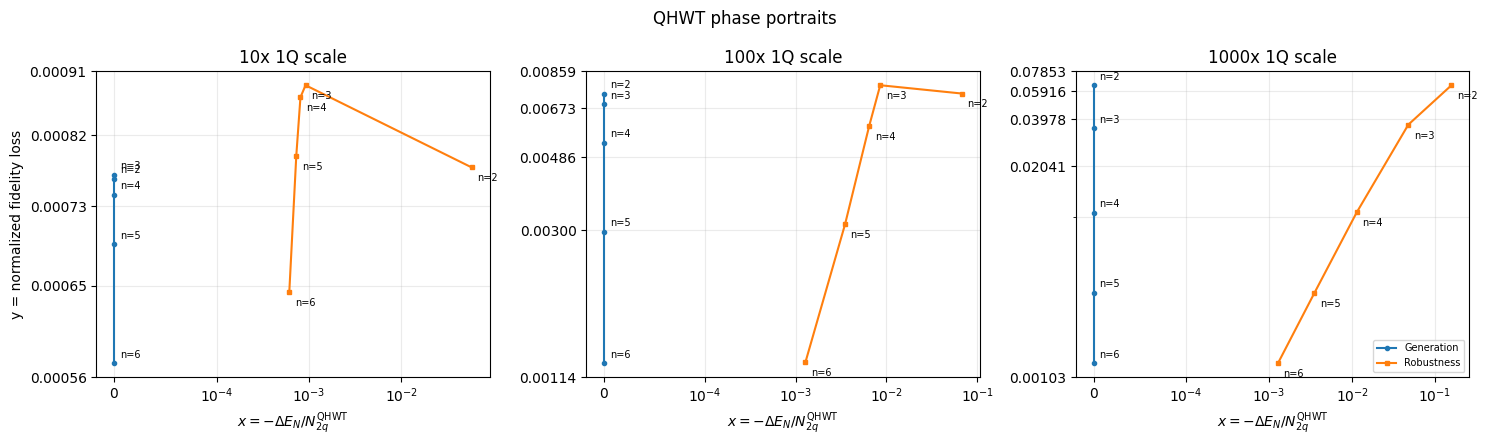

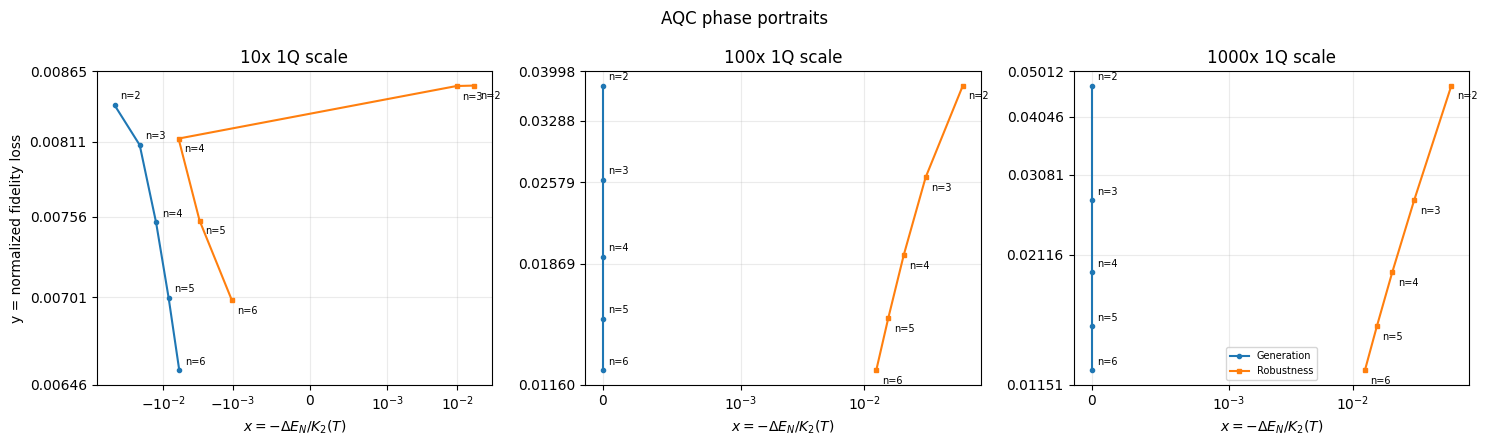

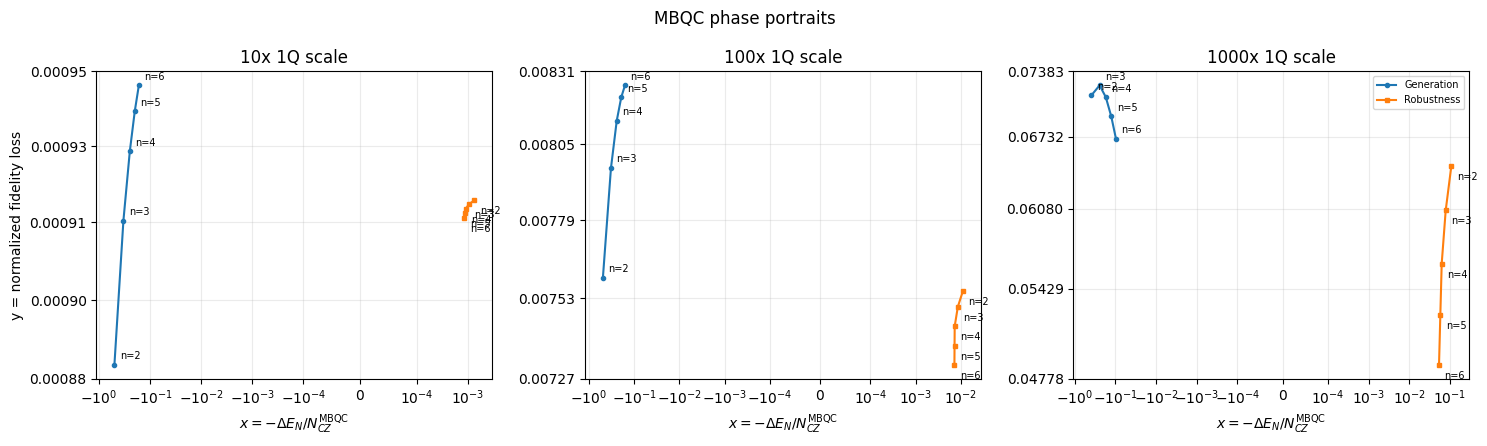


Saved files in cpc_output/:
 - aqc_phase_coordinates.csv
 - figure3_qhwt.png
 - figure4_aqc.png
 - figure5_mbqc.png
 - mbqc_phase_coordinates.csv
 - qhwt_phase_coordinates.csv


In [8]:
# Save numerical results and generate manuscript figures

import os
import csv
import numpy as np
import matplotlib.pyplot as plt


# Save numerical phase-coordinate results

os.makedirs(
    "cpc_output",
    exist_ok=True
)


def save_csv(model_name, data, filename):

    with open(
        filename,
        "w",
        newline=""
    ) as f:

        w = csv.writer(f)

        w.writerow([
            "model",
            "noise_regime",
            "task",
            "n",
            "x",
            "y"
        ])

        for regime, block in data.items():

            for task in (
                "generation",
                "robustness"
            ):

                for item in sorted(
                    block[task],
                    key=lambda z: z[2]
                ):

                    w.writerow([
                        model_name,
                        regime,
                        task,
                        int(item[2]),
                        float(item[0]),
                        float(item[1]),
                    ])


save_csv(
    "QHWT",
    qhwt_data,
    "cpc_output/qhwt_phase_coordinates.csv"
)

save_csv(
    "AQC",
    aqc_data,
    "cpc_output/aqc_phase_coordinates.csv"
)

save_csv(
    "MBQC",
    mbqc_data,
    "cpc_output/mbqc_phase_coordinates.csv"
)


# Generate manuscript phase portraits

def make_three_panel_figure(
    model_name,
    data,
    filename,
    xlabel,
    gen_label,
    rob_label,
    linthresh_x=1e-4,
    linthresh_y=1e-4,
):

    regimes = [
        "2Q noise = 10x 1Q scale",
        "2Q noise = 100x 1Q scale",
        "2Q noise = 1000x 1Q scale",
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.5)
    )

    for ax, regime in zip(
        axes,
        regimes
    ):

        gen = sorted(
            data[regime]["generation"],
            key=lambda z: z[2]
        )

        rob = sorted(
            data[regime]["robustness"],
            key=lambda z: z[2]
        )

        ax.plot(
            [z[0] for z in gen],
            [z[1] for z in gen],
            "-o",
            markersize=3,
            label=gen_label,
        )

        ax.plot(
            [z[0] for z in rob],
            [z[1] for z in rob],
            "-s",
            markersize=3,
            label=rob_label,
        )

        # Label each system size n

        for z in gen:

            ax.annotate(
                f"n={z[2]}",
                (z[0], z[1]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
            )

        for z in rob:

            ax.annotate(
                f"n={z[2]}",
                (z[0], z[1]),
                xytext=(4, -10),
                textcoords="offset points",
                fontsize=7,
            )


        # Symmetric-logarithmic scaling on both axes.

        ax.set_xscale(
            "symlog",
            linthresh=linthresh_x
        )

        ax.set_yscale(
            "symlog",
            linthresh=linthresh_y
        )


        # Grid

        ax.grid(
            True,
            which="both",
            alpha=0.25
        )


        # Show numerical y-axis values while preserving each panel's automatic range.

        ymin, ymax = ax.get_ylim()

        yticks = np.linspace(
            ymin,
            ymax,
            5
        )

        ax.set_yticks(
            yticks
        )

        ax.set_yticklabels(
            [
                f"{value:.5f}"
                for value in yticks
            ]
        )

        # Restore the automatically chosen limits after setting ticks.
        ax.set_ylim(
            ymin,
            ymax
        )


        # Titles and x labels

        ax.set_title(
            regime.replace(
                "2Q noise = ",
                ""
            )
        )

        ax.set_xlabel(
            xlabel
        )


    # Shared y-axis description

    axes[0].set_ylabel(
        "y = normalized fidelity loss"
    )


    # Legend

    axes[-1].legend(
        fontsize=7,
        loc="best"
    )


    # Figure title

    fig.suptitle(
        f"{model_name} phase portraits"
    )


    fig.tight_layout()


    # Save

    fig.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# Figure 3 — QHWT

make_three_panel_figure(
    "QHWT",
    qhwt_data,
    "cpc_output/figure3_qhwt.png",
    r"$x=-\Delta E_N/N_{2q}^{\rm QHWT}$",
    "Generation",
    "Robustness",
    linthresh_x=1e-4,
    linthresh_y=1e-5,
)


# Figure 4 — AQC

make_three_panel_figure(
    "AQC",
    aqc_data,
    "cpc_output/figure4_aqc.png",
    r"$x=-\Delta E_N/K_2(T)$",
    "Generation",
    "Robustness",
    linthresh_x=1e-3,
    linthresh_y=1e-3,
)


# Figure 5 — MBQC

make_three_panel_figure(
    "MBQC",
    mbqc_data,
    "cpc_output/figure5_mbqc.png",
    r"$x=-\Delta E_N/N_{CZ}^{\rm MBQC}$",
    "Generation",
    "Robustness",
    linthresh_x=1e-4,
    linthresh_y=1e-4,
)


# List generated files

print(
    "\nSaved files in cpc_output/:"
)

for name in sorted(
    os.listdir("cpc_output")
):

    print(
        " -",
        name
    )